# Complete Analysis Pipeline: ZCI Computation

This notebook implements the complete **Zoobenthic Community Indicator (ZCI)** analysis pipeline, integrating all four analysis stages from the `zci` package:

## Pipeline Stages

1. **Stage 1: Contamination Assessment** (`zci.contamination_assessment`)
   - PCA-based pollution scoring from chemical variables
   - RDA validation of pollution gradients against species

2. **Stage 2: Taxa Assemblage on Reference Sites** (`zci.taxa_assemblage_in_refs`)
   - Reference site selection based on pollution scores
   - Hierarchical clustering of species composition
   - Cluster visualization and analysis

3. **Stage 3: Environment-Driven Taxa Clusters** (`zci.env_driven_taxa_clusters`)
   - RDA analysis linking environmental variables to taxa composition
   - LDA classification with Monte Carlo cross-validation
   - Prediction of non-reference site clusters

4. **Stage 4: Community Composition Ordination** (`zci.community_composition_measures`)
   - Cluster-specific PCA on transformed species data
   - ZCI calculation (compositional distance from reference)
   - Taxa loadings and ordination visualization

---

## Parameter Organization

All parameters are organized into categories:
- **KEY_PARAMS**: Explicitly assigned core parameters for each stage
- **MODEL_PARAMS**: Statistical model settings (nested into KEY_PARAMS)
- **FIGURE_PARAMS**: Visualization settings (nested into KEY_PARAMS)
- **DATA_PARAMS**: Data paths and column names

In [330]:
# =============================================================================
# IMPORTS AND SETUP
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("✓ Base imports loaded successfully!")

✓ Base imports loaded successfully!


## Configuration: Parameter Pool

The parameters are organized hierarchically:
1. **KEY_PARAMS** - Core parameters that are explicitly assigned and most commonly modified
2. **MODEL_PARAMS** - Statistical model settings (nested into KEY_PARAMS where appropriate)
3. **FIGURE_PARAMS** - All visualization settings
4. **DATA_PARAMS** - Data paths and column specifications

In [331]:
# =============================================================================
# PARAMETER CONFIGURATION - HIERARCHICAL ORGANIZATION
# =============================================================================

# -----------------------------------------------------------------------------
# DATA PARAMETERS - Input data paths and column specifications
# -----------------------------------------------------------------------------
DATA_PARAMS = {
    'data_path': "../data/processed/complete_env_taxa_chemical.xlsx",
    'sheet_name': "all_data_merged",
    'pollution_column': 'Pollution_Score',      # Column name for pollution scores
    'cluster_column': 'clusters',               # Column name for cluster labels
    'ref_column': 'if_ref',                     # Column for reference site indicator
}

# =============================================================================
# KEY PARAMETERS - EXPLICITLY ASSIGNED CORE PARAMETERS (Simplified)
# =============================================================================
# These are the most important parameters that users typically need to modify.
# Nested within each stage are visualization, model, and output settings.
# =============================================================================

KEY_PARAMS = {
    # =========================================================================
    # STAGE 1: Contamination Assessment
    # =========================================================================
    'stage1': {
        # --- CORE PARAMETERS ---
        'transform_method': 'log_z_score',      # 'log_z_score', 'robust_scaler'
        'pc_weights': {
            'PC1': 1.0, 'PC2': 1.0, 'PC3': 1.0,
            'PC4': 0.0, 'PC5': 1.0, 'PC6': 1.0,
        },
        'save_individual_pcs': True,
        
        # --- MODEL SETTINGS ---
        'standardize_pca_scores': True,
        'run_rda_validation': True,
        'rda_percentile_threshold': 40,
    },
    
    # =========================================================================
    # STAGE 2: Taxa Assemblage on Reference Sites
    # =========================================================================
    'stage2': {
        # --- CORE PARAMETERS ---
        'reference_percentile': 50,
        'species_transformation': 'hellinger',
        'n_clusters': 3,
        'top_n_taxa': 16,
        
        'env_variables': [
            'Measured Depth (m)',
            'Velocity  at bottom (m/sec)_Imputed',
            'Water DO Bottom (mg/L)',
            'Temperature (oC)',
            'MPS (Phi)',
            'LOI (%)'
        ],
        
        # --- MODEL SETTINGS ---
        'linkage_method': 'ward',
        
        # --- VISUALIZATION SETTINGS ---
        'create_cluster_visualization': True,
        'create_dendrogram_comparison': True,
        'create_ward_analysis': True,
        'create_comparison_plots': True,
        'label_positions': [90, 250, 380],
    },
    
    # =========================================================================
    # STAGE 3: Environment-Driven Taxa Clusters (RDA + LDA)
    # =========================================================================
    'stage3': {
        # --- CORE PARAMETERS ---
        'rda_n_permutations': 999,
        'lda_n_iterations': 1000,
        'taxa_transformation': 'hellinger',
        'top_n_taxa_rda': None,
        'lda_log_transform_env': False,
        
        # --- MODEL SETTINGS ---
        'rda_log_transform_env': False,
        'rda_standardize_env': True,
        'lda_standardize_env': True,
        'lda_test_size': 0.2,
        'random_state': 42,
        
        # --- VISUALIZATION SETTINGS ---
        'rda_arrow_scale': 0.5,
        'rda_species_scale': 0.5,
        'rda_figsize': (14, 10),
        'lda_arrow_scale': 2,
        'lda_cv_figsize': (14, 9),
    },
    
    # =========================================================================
    # STAGE 4: Community Composition Ordination (PCA-based ZCI)
    # =========================================================================
    'stage4': {
        # --- CORE PARAMETERS ---
        'taxa_transformation': 'hellinger',
        'training_percentile': 100.0,
        'top_n_taxa': 16,
        
        # PC specifications (1-indexed)
        'taxa_loadings_pcs': {
            0: (1, 2, 3, 4, 5),
            1: (1, 2, 3, 4, 5, 6),
            2: (1, 2, 3, 4),
        },
        'zci_pc_planes': None,
        
        # ZCI Method
        'zci_method': 'least_pollution_threshold',
        'least_pollution_threshold': 15,
        
        # --- MODEL SETTINGS ---
        'variance_threshold': 0.70,
        'pc_variance_threshold': 5.0,
        'normalize_pcs': False,
        'pollution_pc_prefix': 'Pollution_PC',
        'use_consistent_taxa_order': True,
        'random_state': 42,
        
        # --- VISUALIZATION SETTINGS ---
        'create_taxa_loadings_plot': True,
        'create_pc_loadings_plot': True,
        'create_ordination_plot': True,
        'create_zci_plot': True,
        'create_pc_regression_plot': True,
        'create_pollution_vs_species_pc_plot': True,
        'create_comprehensive_plot': False,
        'pc_plane': (1, 2),
        'pc_loadings_top_n_taxa': None,
        'pc_loadings_show_values': False,
        'taxa_loadings_figsize': (14, 12),
        'ordination_figsize': (18, 6),
        'zci_figsize': (16, 10),
    },
    
    # =========================================================================
    # GENERAL SETTINGS
    # =========================================================================
    'verbose': True,
    'random_state': 42,
}

print("=" * 80)
print("✓ PARAMETERS CONFIGURED")
print("=" * 80)

✓ PARAMETERS CONFIGURED


In [332]:
# =============================================================================
# OUTPUT PARAMETERS - Save paths and settings
# =============================================================================

from datetime import datetime

# Generate timestamp for this run
RUN_TIMESTAMP = datetime.now().strftime("%m_%d_%H_%M")

# Base results directory (relative to notebook location)
RESULTS_DIR = "../results"

# Output configuration
OUTPUT_PARAMS = {
    'save_figures': True,                       # Save all figures
    'save_tables': True,                        # Save all tables
    'save_parameters': True,                    # Save parameter configuration
    'figure_formats': ['png'],                  # Output formats
    'figure_dpi': 300,                          # Resolution
    'timestamp': RUN_TIMESTAMP,
}

# Construct full paths for each stage
FIGURE_PATHS = {
    1: f"{RESULTS_DIR}/figures/01_contamination_assessment",
    2: f"{RESULTS_DIR}/figures/02_taxa_assemblage_in_refs",
    3: f"{RESULTS_DIR}/figures/03_env_driven_taxa_clusters",
    4: f"{RESULTS_DIR}/figures/04_community_composition_measures",
}

TABLE_PATHS = {
    1: f"{RESULTS_DIR}/tables/01_contamination_assessment",
    2: f"{RESULTS_DIR}/tables/02_taxa_assemblage_in_refs",
    3: f"{RESULTS_DIR}/tables/03_env_driven_taxa_clusters",
    4: f"{RESULTS_DIR}/tables/04_community_composition_measures",
}

print("✓ Output parameters configured")
print(f"  - Run timestamp: {RUN_TIMESTAMP}")
print(f"  - Save figures: {OUTPUT_PARAMS['save_figures']}")
print(f"  - Save tables: {OUTPUT_PARAMS['save_tables']}")

✓ Output parameters configured
  - Run timestamp: 01_21_00_24
  - Save figures: True
  - Save tables: True


---

## Stage 1: Contamination Assessment

**Objective**: Compute pollution scores from chemical variables using PCA-based weighted scoring.

**Key Parameters**:
- `transform_method`: How to transform raw pollution data before PCA
- `pc_weights`: Weights for combining principal components into final score


STAGE 1: CONTAMINATION ASSESSMENT
✓ Loaded data: 104 sites, 59 variables
CONTAMINATION ASSESSMENT PIPELINE

[Step 1/7] Extracting and preparing pollution data...
  ✓ Extracted 30 pollution variables from 104 sites

[Step 2/7] Applying transformation (method: log_z_score)...
  ✓ Applied log transformation (except As, Bi)
  ✓ Applied z-score standardization

[Step 3/7] Ordering variables by hierarchical clustering...
  ✓ Variables reordered by similarity

[Step 4/7] Performing PCA on transformed pollution data...


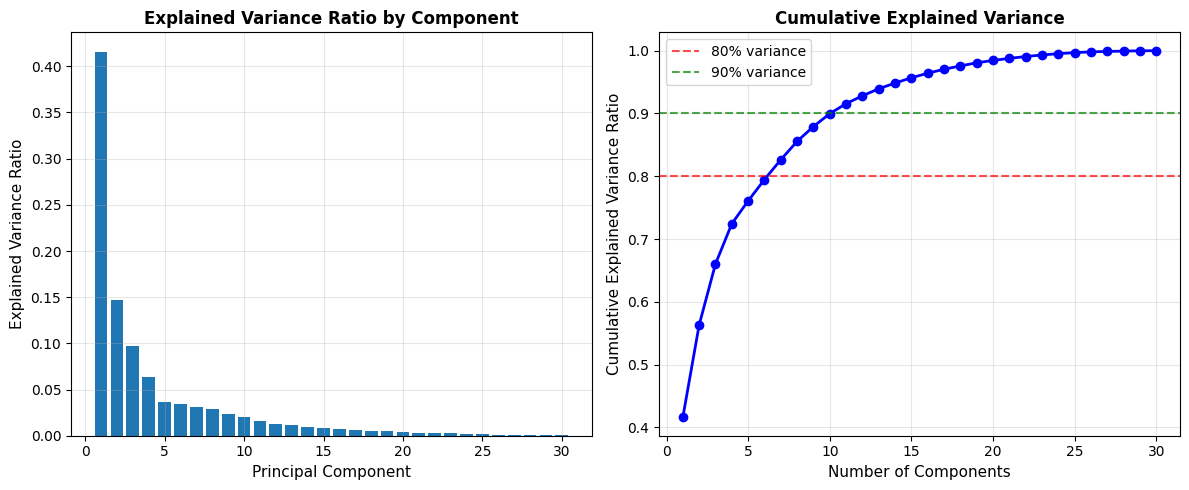

  ✓ Extracted 6 principal components
  ✓ PC loadings shape: (30, 6)
  ✓ PC scores shape: (104, 6)
  ✓ PC scores standardized (mean=0, std=1)

[Step 5/7] Creating visualizations...
  ✓ Ridge plot of PC loadings created

[Step 6/7] Running RDA validation (percentile threshold: 40)...
Hellinger transformation completed.
Original taxa data shape: (104, 16)

Percentile threshold: 40th percentile = -0.8306
Number of reference sites: 42
Number of contaminated sites: 62

Reference taxa data shape: (42, 16)
Reference habitat (PC scores) data shape: (42, 6)

Fitting RDA model...

✓ RDA triplot created successfully!
✓ RDA1 + RDA2 explain 58.95% of constrained variance
  ✓ RDA validation completed

[Step 7/7] Computing weighted pollution scores and merging into data...
  ✓ Using custom weights: {'PC1': 1.0, 'PC2': 1.0, 'PC3': 1.0, 'PC4': 0.0, 'PC5': 1.0, 'PC6': 1.0}
  ✓ Pollution scores added to data
  ✓ Multi-index column: ('pollution', 'weighted', 'SumRel')
  ✓ Raw data column: 'Pollution_Score'

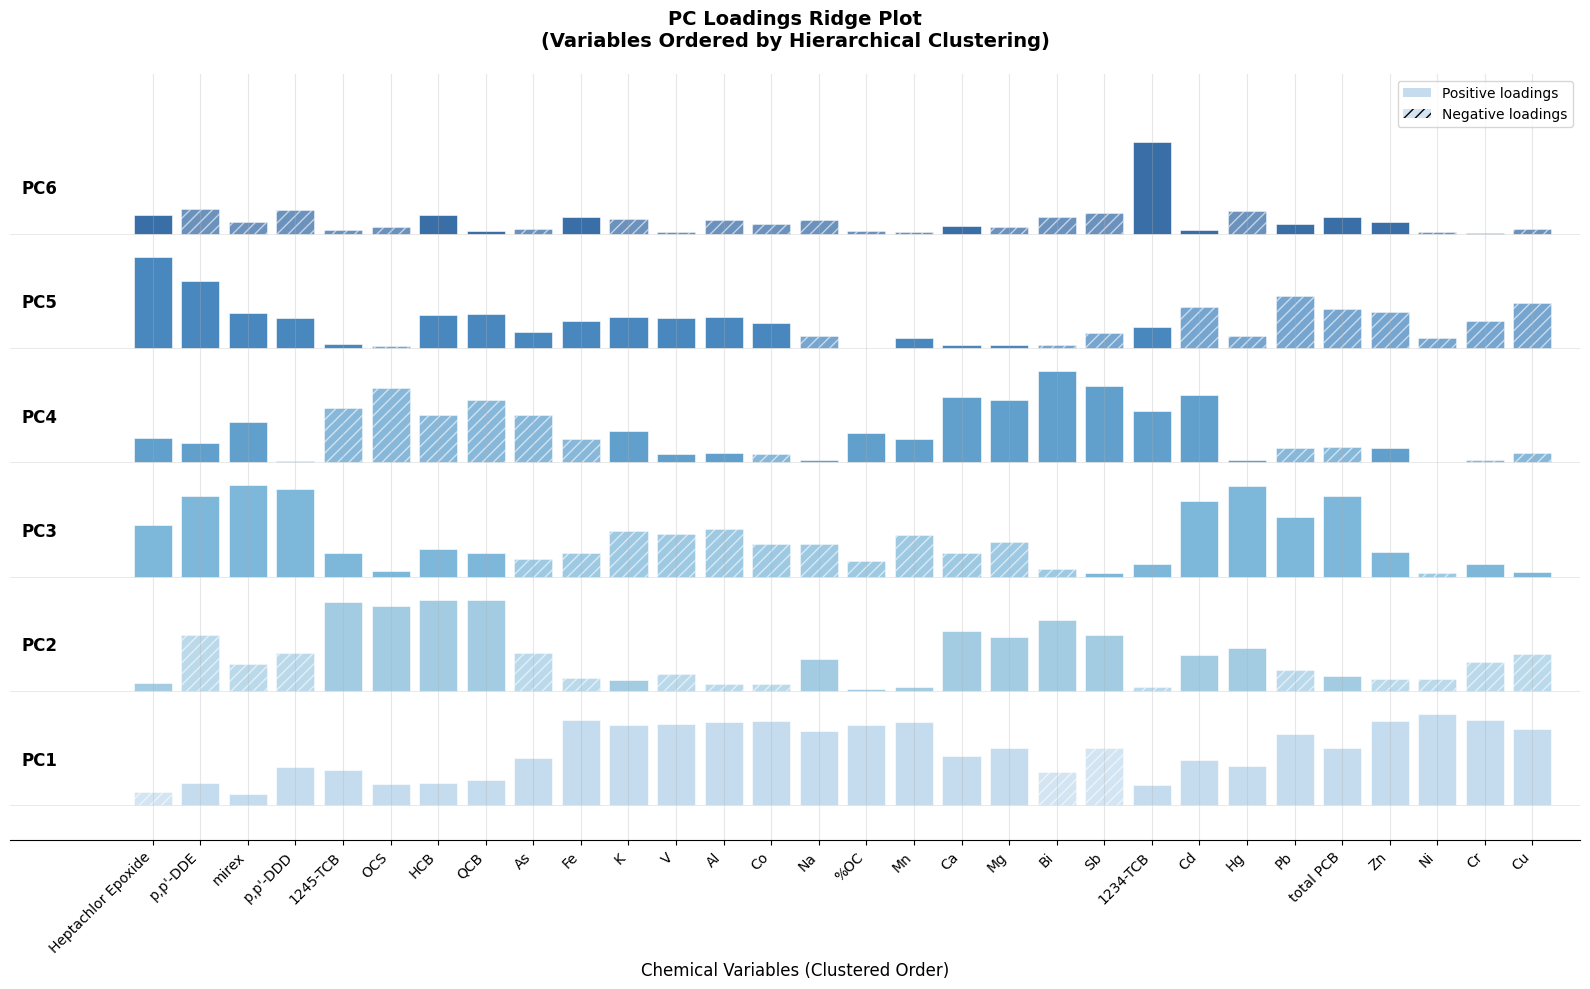

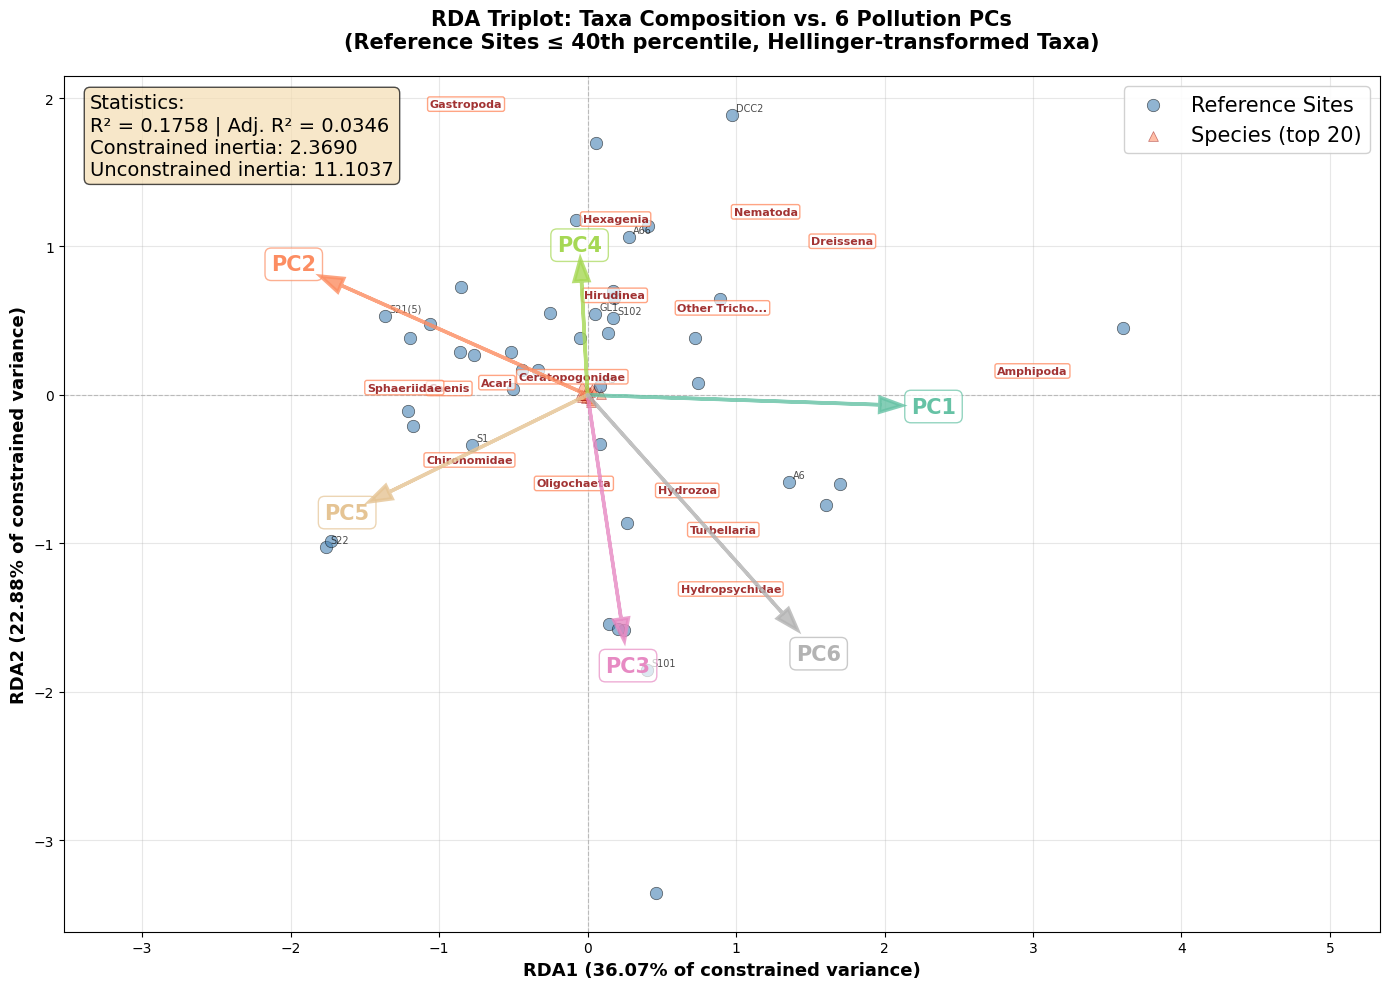

In [333]:
# =============================================================================
# STAGE 1: CONTAMINATION ASSESSMENT
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 1: CONTAMINATION ASSESSMENT")
print("=" * 80)

# Load data
data_input = pd.read_excel(
    DATA_PARAMS['data_path'],
    sheet_name=DATA_PARAMS['sheet_name'],
    header=[0, 1, 2],
    index_col=0
)
print(f"✓ Loaded data: {data_input.shape[0]} sites, {data_input.shape[1]} variables")

# Reload module to pick up changes
import importlib
import sys
modules_to_remove = [key for key in sys.modules.keys() if 'zci.contamination_assessment' in key]
for mod in modules_to_remove:
    del sys.modules[mod]

# Import and run contamination assessment pipeline
from zci.contamination_assessment import pipeline as contamination_pipeline

cfg_s1 = KEY_PARAMS['stage1']

# Determine save paths
save_path_s1 = FIGURE_PATHS[1] if OUTPUT_PARAMS['save_figures'] else None
table_save_path_s1 = TABLE_PATHS[1] if OUTPUT_PARAMS['save_tables'] else None

stage1_results = contamination_pipeline.contamination_assessment_pipeline(
    data_input,
    transform_method=cfg_s1['transform_method'],
    standardize_pca_scores=cfg_s1['standardize_pca_scores'],
    pc_weights=cfg_s1['pc_weights'],
    run_rda_validation=cfg_s1['run_rda_validation'],
    rda_percentile_threshold=cfg_s1['rda_percentile_threshold'],
    save_individual_pcs=cfg_s1['save_individual_pcs'],
    save_path=save_path_s1,
    save_tables=OUTPUT_PARAMS['save_tables'],
    table_save_path=table_save_path_s1,
)

# Extract outputs
raw_data_s1 = stage1_results['raw_data']
multiindex_data_s1 = stage1_results['multiindex_data']

print(f"\n✓ Stage 1 Complete!")
print(f"  - Pollution scores range: [{raw_data_s1['Pollution_Score'].min():.2f}, {raw_data_s1['Pollution_Score'].max():.2f}]")

# Verify individual PCs
pollution_pc_cols = [c for c in raw_data_s1.columns if c.startswith('Pollution_PC')]
print(f"  - Individual pollution PCs saved: {pollution_pc_cols}")

# Report saved figures
if 'figures' in stage1_results and OUTPUT_PARAMS['save_figures']:
    print(f"  - Figures saved: {len(stage1_results['figures'])} to {save_path_s1}")

# Report saved tables
if 'tables' in stage1_results and OUTPUT_PARAMS['save_tables']:
    print(f"  - Tables saved: {len(stage1_results['tables'])} to {table_save_path_s1}")

In [334]:
# =============================================================================
# VERIFY SAVED TABLE CONTENTS
# =============================================================================

print("=" * 80)
print("STAGE 1 TABLE OUTPUTS")
print("=" * 80)

# Display the saved tables from stage1_results
if 'tables' in stage1_results:
    for name, df in stage1_results['tables'].items():
        print(f"\n📊 {name.upper()}:")
        display(df.round(4))

STAGE 1 TABLE OUTPUTS

📊 PCA_LOADINGS:


,PC1,PC2,PC3,PC4,PC5,PC6
var,,,,,,
%OC,0.2398,0.0102,-0.0619,0.1267,0.0017,-0.0274
1234-TCB,0.0615,-0.0146,0.0493,0.2244,0.1144,0.7924
1245-TCB,0.1046,0.3572,0.0924,-0.2376,0.0223,-0.0311
Al,0.2492,-0.0293,-0.1890,0.0399,0.1703,-0.1193
As,0.1424,-0.1519,-0.0708,-0.2066,0.0894,-0.0452
Bi,-0.0995,0.2882,-0.0307,0.3978,-0.0163,-0.1473
Ca,0.1489,0.2410,-0.0924,0.2842,0.0188,0.0651
Cd,0.1345,0.1453,0.2956,0.2916,-0.2262,0.0348
Co,0.2530,-0.0280,-0.1276,-0.0369,0.1393,-0.0863



📊 RDA_AXES_SUMMARY:


,Axis,Eigenvalue,Expl. (%),Cumul. (%),F-stat,p-value
0,RDA1,0.0208,36.0749,36.0749,2.6938,0.324
1,RDA2,0.0132,22.8800,58.9549,1.7085,0.885
2,RDA3,0.0088,15.1661,74.1211,1.1325,0.999
3,RDA4,0.0073,12.6117,86.7328,0.9418,1.000
4,RDA5,0.0044,7.6547,94.3875,0.5716,1.000
5,RDA6,0.0032,5.6125,100.0000,0.4191,1.000



📊 RDA_PREDICTOR_TERMS:


,Variable,Δ Inertia,F-stat,p-value,RDA1,RDA2
0,PC1,0.3345,1.0545,0.387,0.7060,-0.0236
1,PC2,0.4795,1.5113,0.116,-0.5998,0.2667
2,PC3,0.3042,0.9589,0.469,0.0826,-0.5524
3,PC4,0.4403,1.3878,0.173,-0.0164,0.3057
4,PC5,0.4510,1.4215,0.159,-0.4908,-0.2401
5,PC6,0.2607,0.8216,0.592,0.4716,-0.5281


---

## Stage 2: Taxa Assemblage on Reference Sites

**Objective**: Identify reference sites (least polluted) and cluster them by species composition to define habitat types.

**Key Parameters**:
- `reference_percentile`: Bottom X% of sites selected as reference
- `species_transformation`: How to transform species data before clustering
- `n_clusters`: Number of habitat clusters to identify


STAGE 2: TAXA ASSEMBLAGE ON REFERENCE SITES
REFERENCE SITES TAXA ASSEMBLAGE PIPELINE

Configuration:
  - Reference percentile: 50%
  - Species transformation: hellinger
  - Linkage method: Ward's
  - Number of clusters: 3
  - Top taxa to display: 16
  - Run Box-Cox ANOVA: True
  - Save path: ../results/figures/02_taxa_assemblage_in_refs

STEP 1: Imputing velocity values...
VELOCITY IMPUTATION FOR SCDRS SITES

Detroit River baseline: 0.188 m/s (median of 18 sites)

[Lake St. Clair Imputation]
  LSC sites: 66
  Delta zone sites: 34
  Velocity range: -0.054 to 0.329 m/s
  Median velocity (all): 0.045 m/s
  Median velocity (delta): 0.094 m/s

[St. Clair River Imputation]
  SCR sites: 20
  Velocity range: 0.085 to 0.306 m/s
  Median velocity: 0.176 m/s
  Ratio to DR median: 0.94x

Creating visualizations...

IMPUTATION COMPLETED SUCCESSFULLY

Summary:
  Total sites: 104
  Sites with imputed values: 86
  Sites with recorded values: 18
  ✓ Velocity imputation complete

STEP 2: Selecting refe

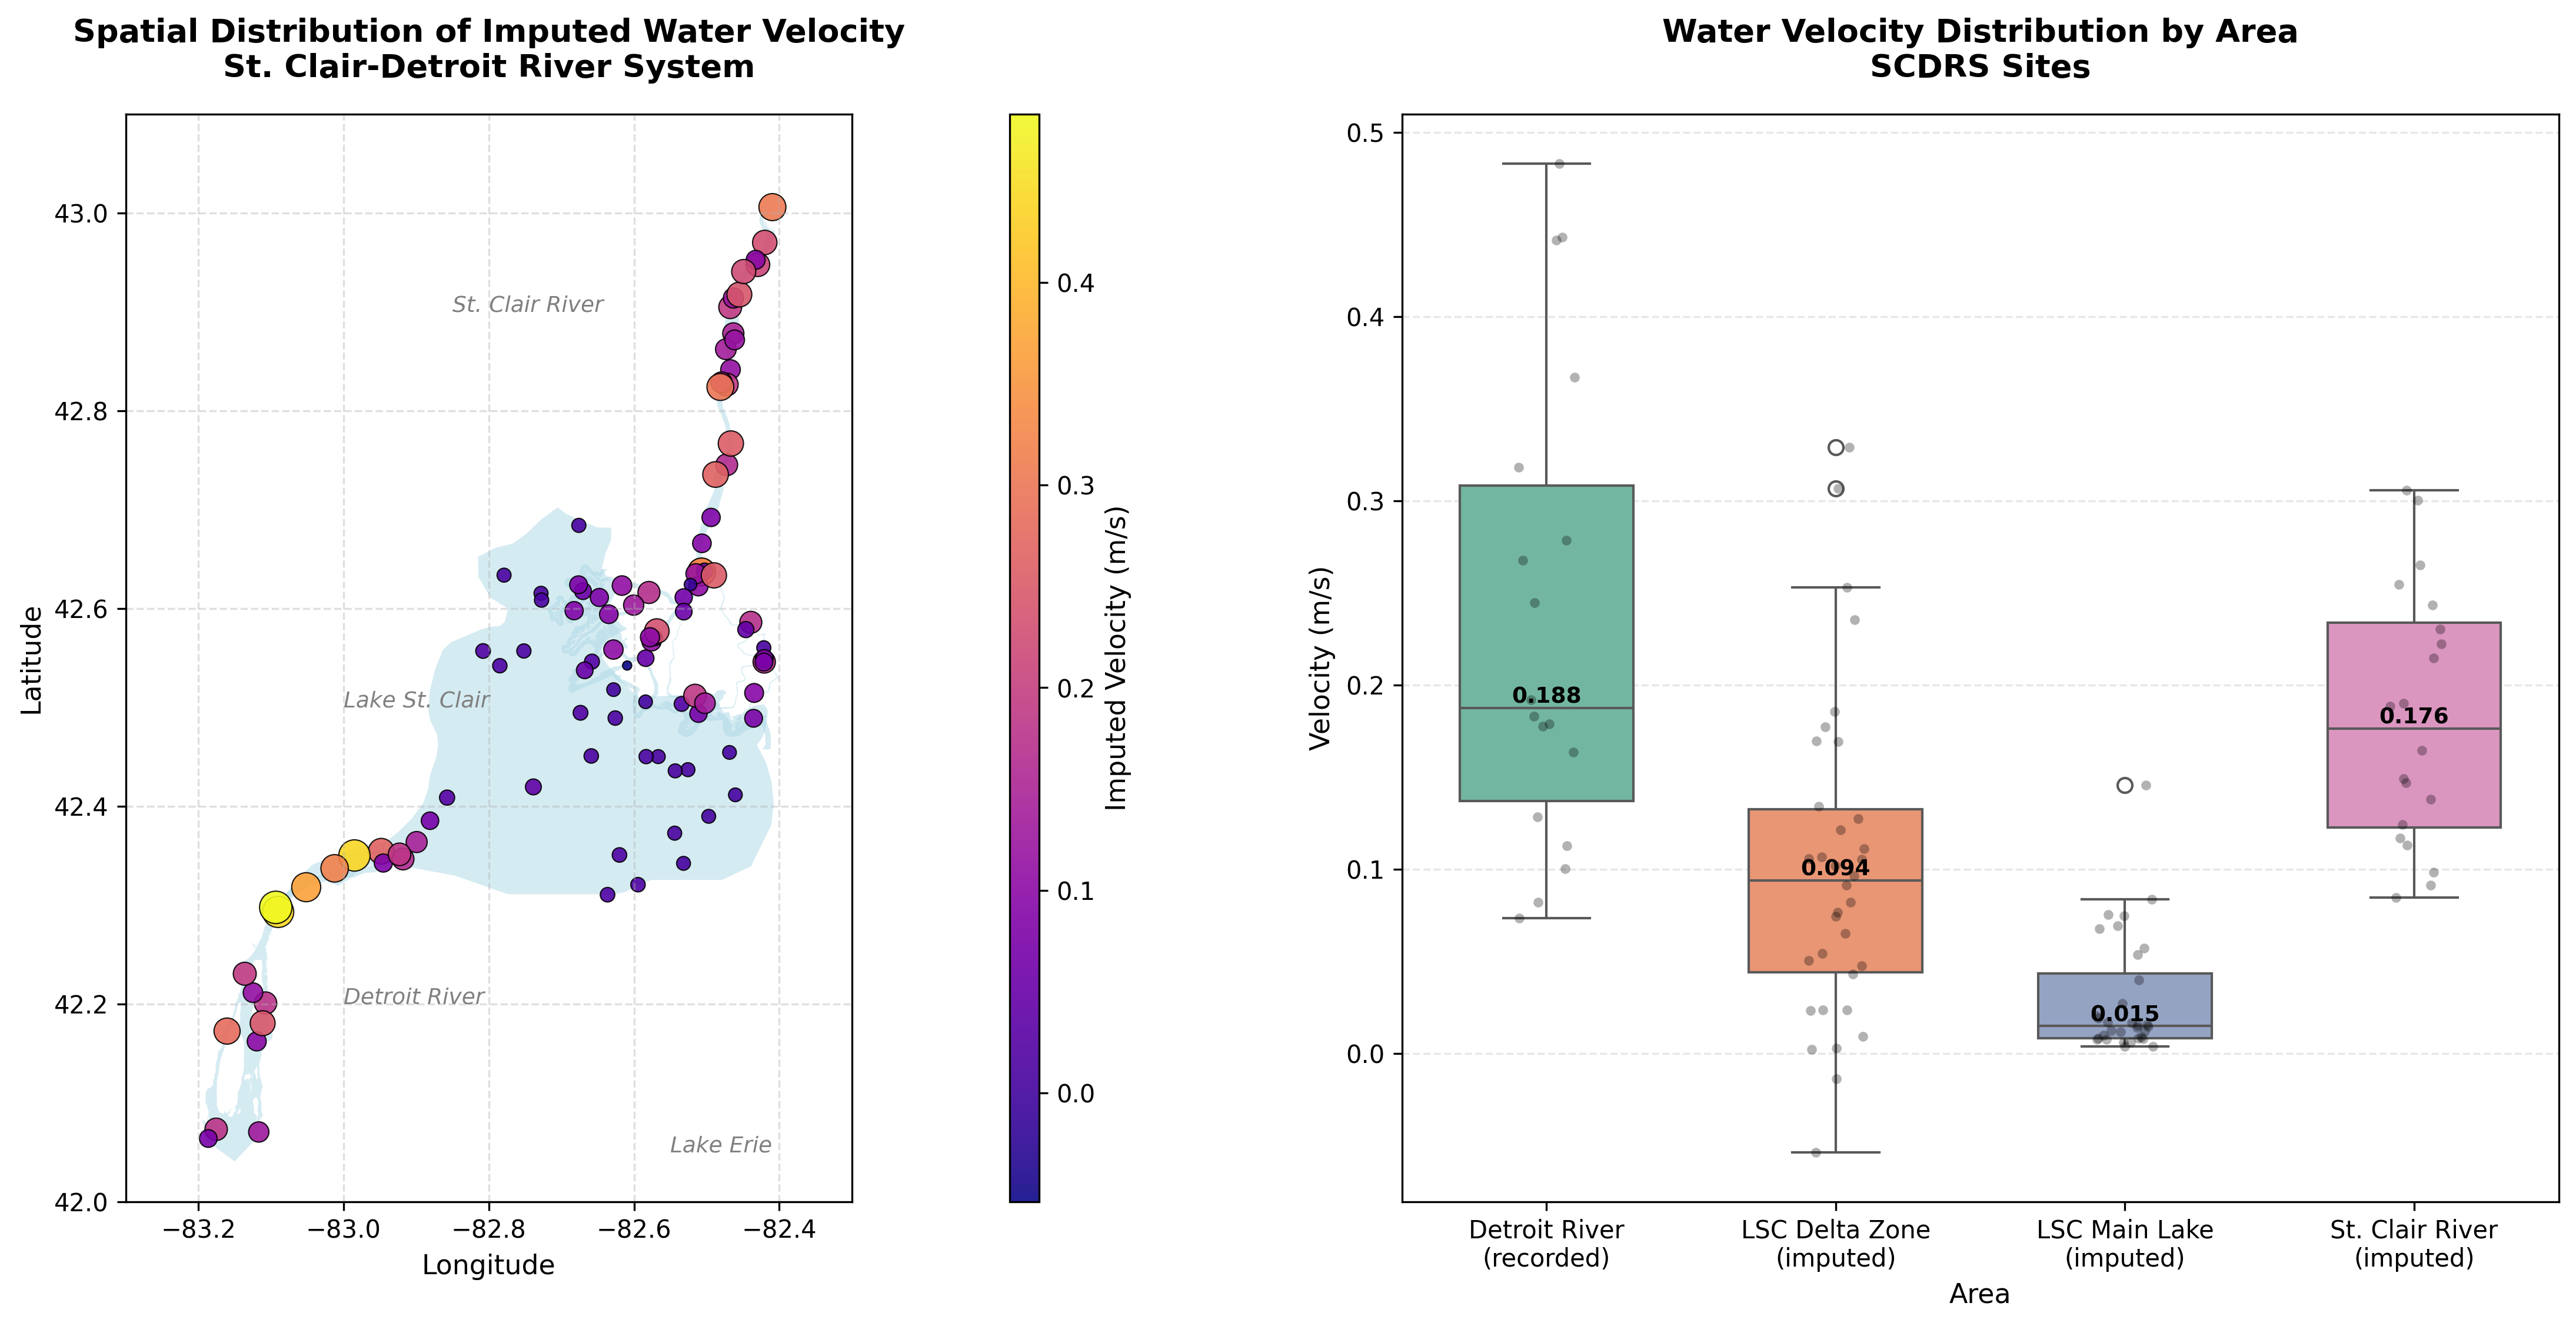

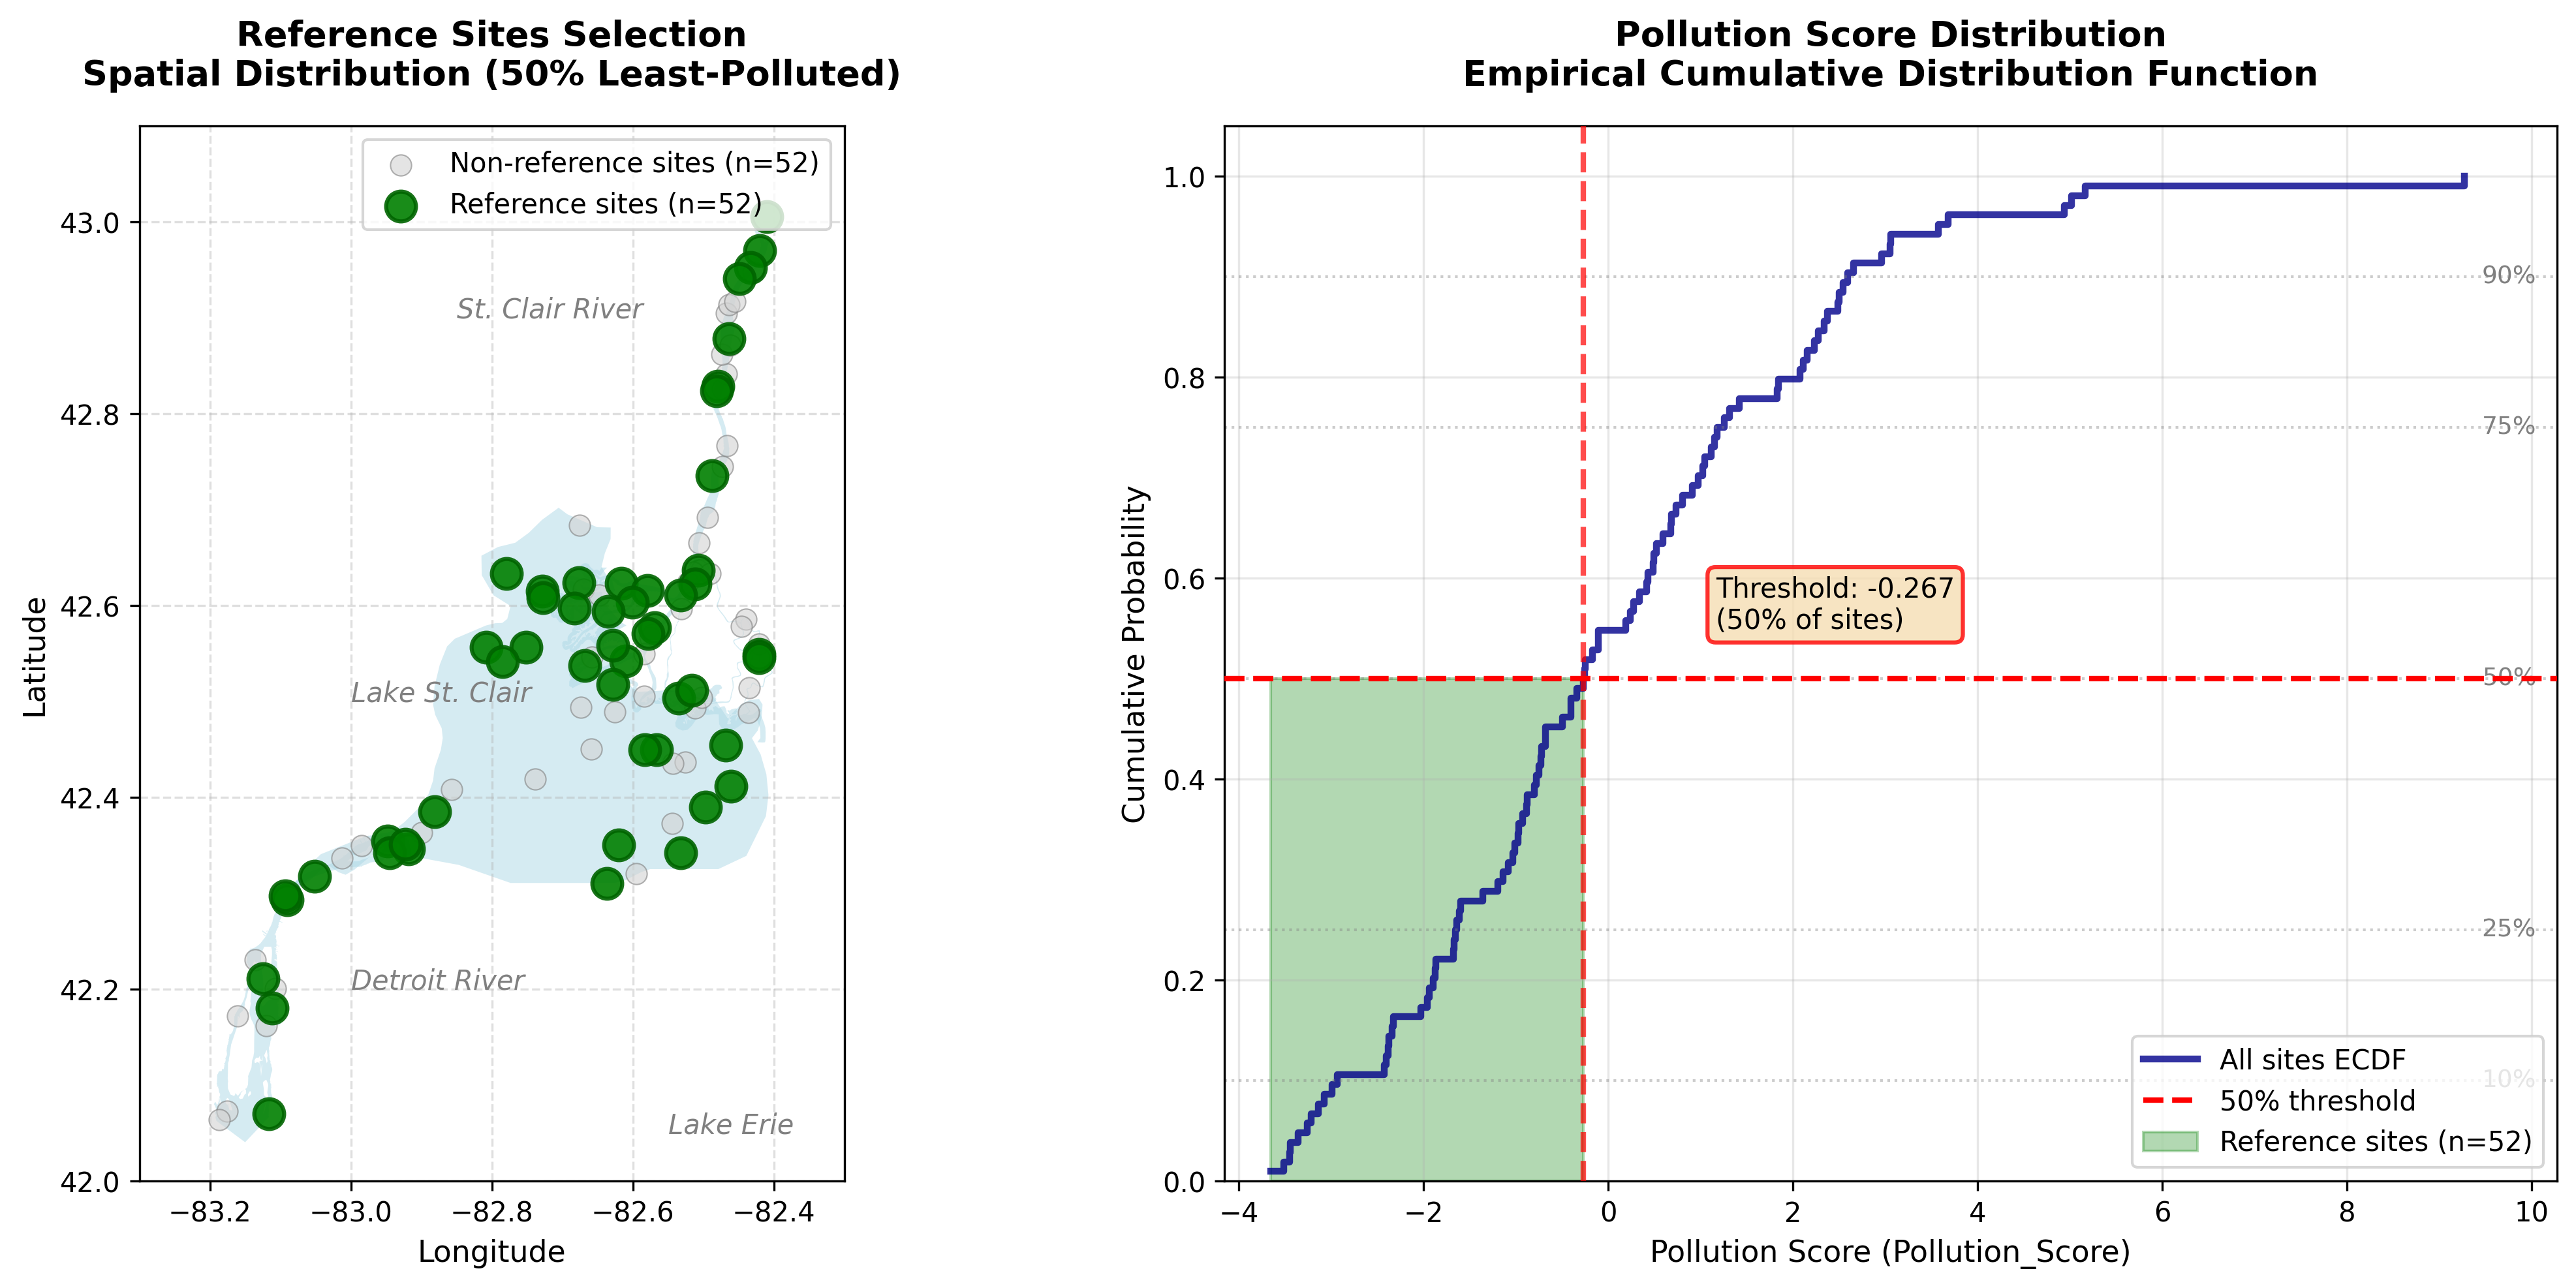

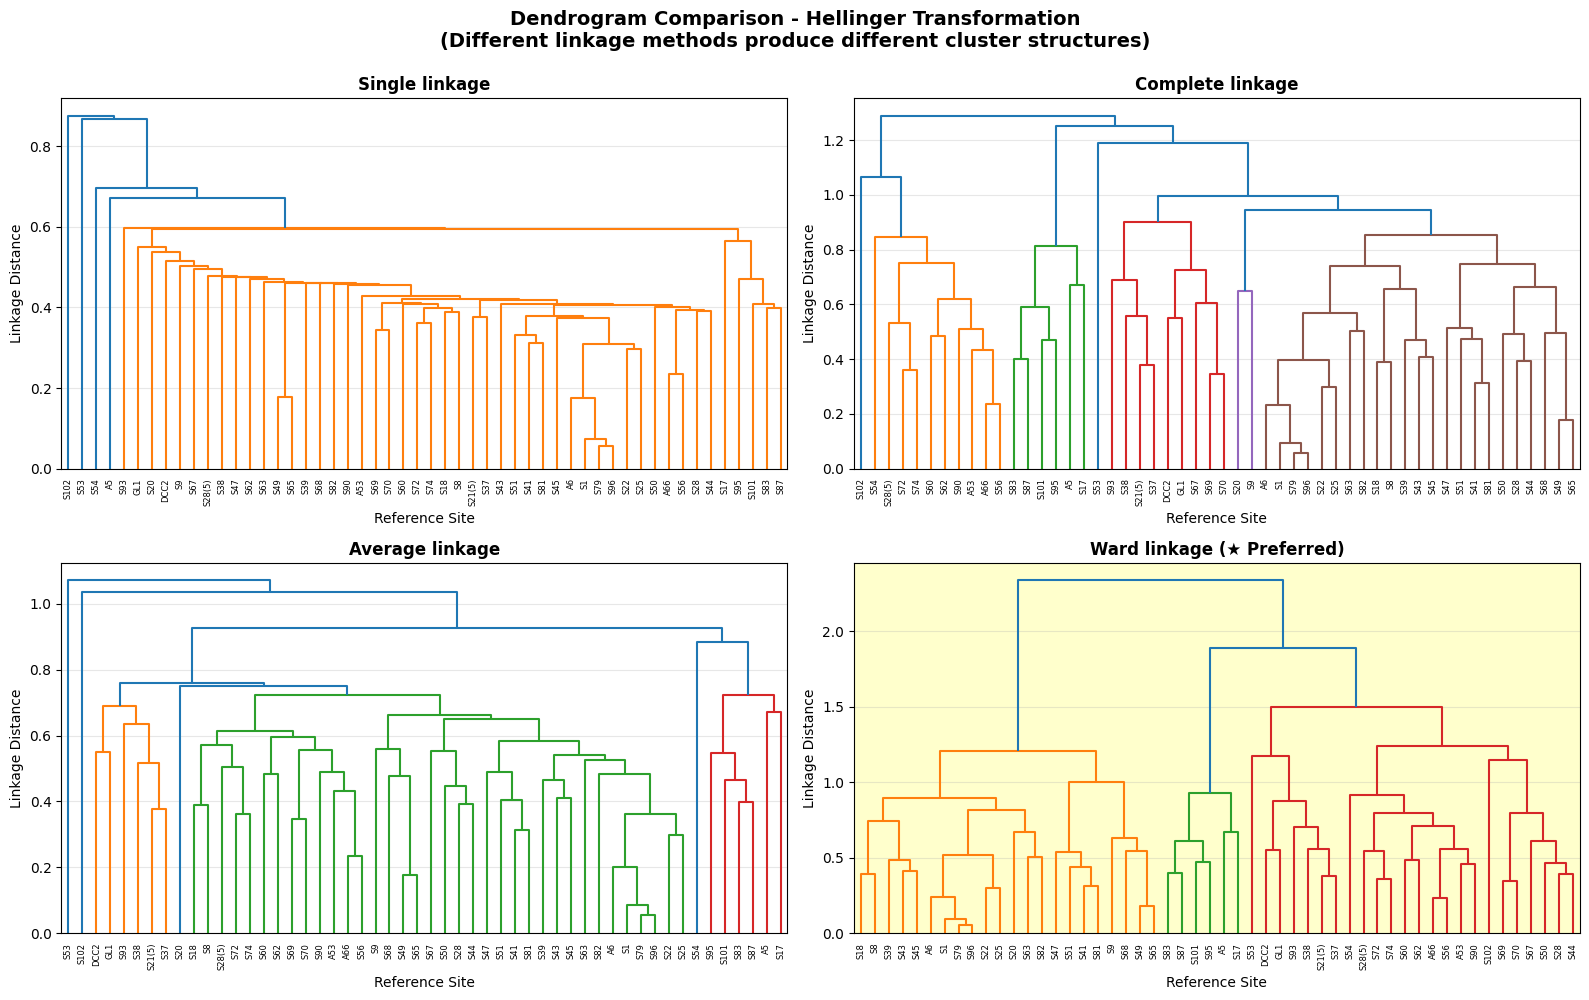

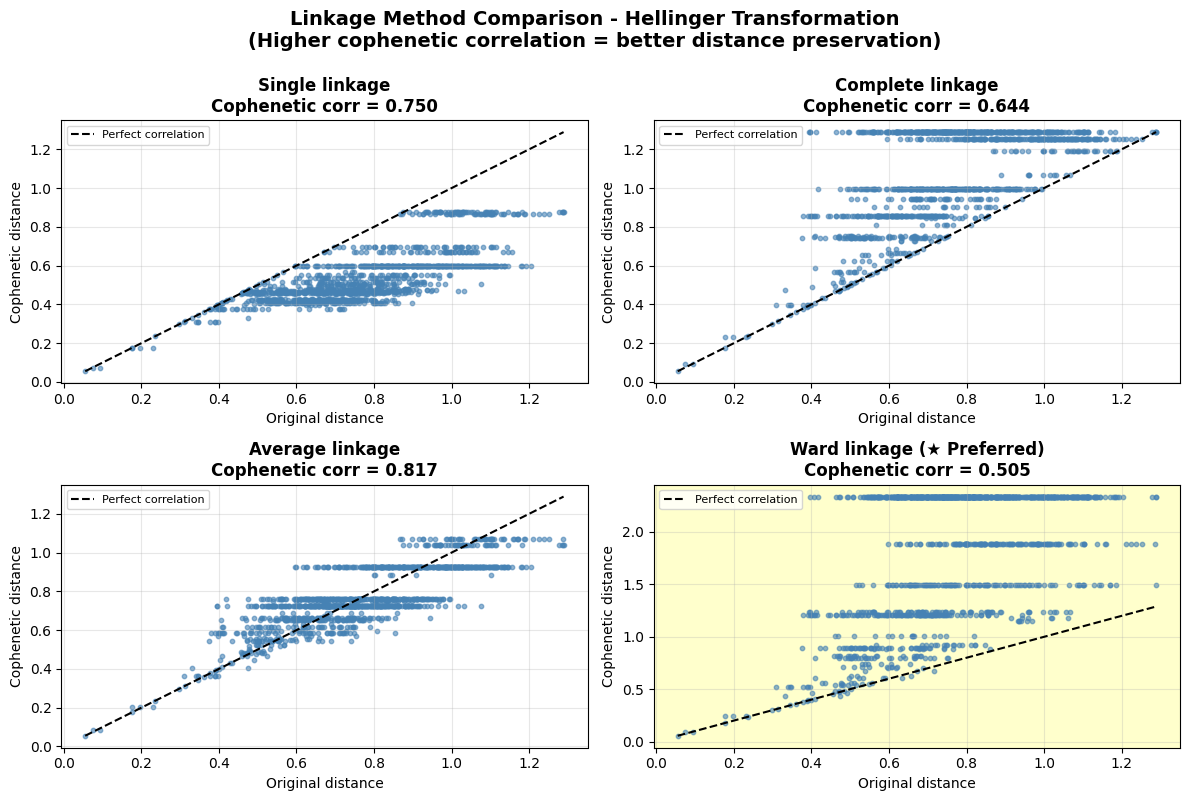

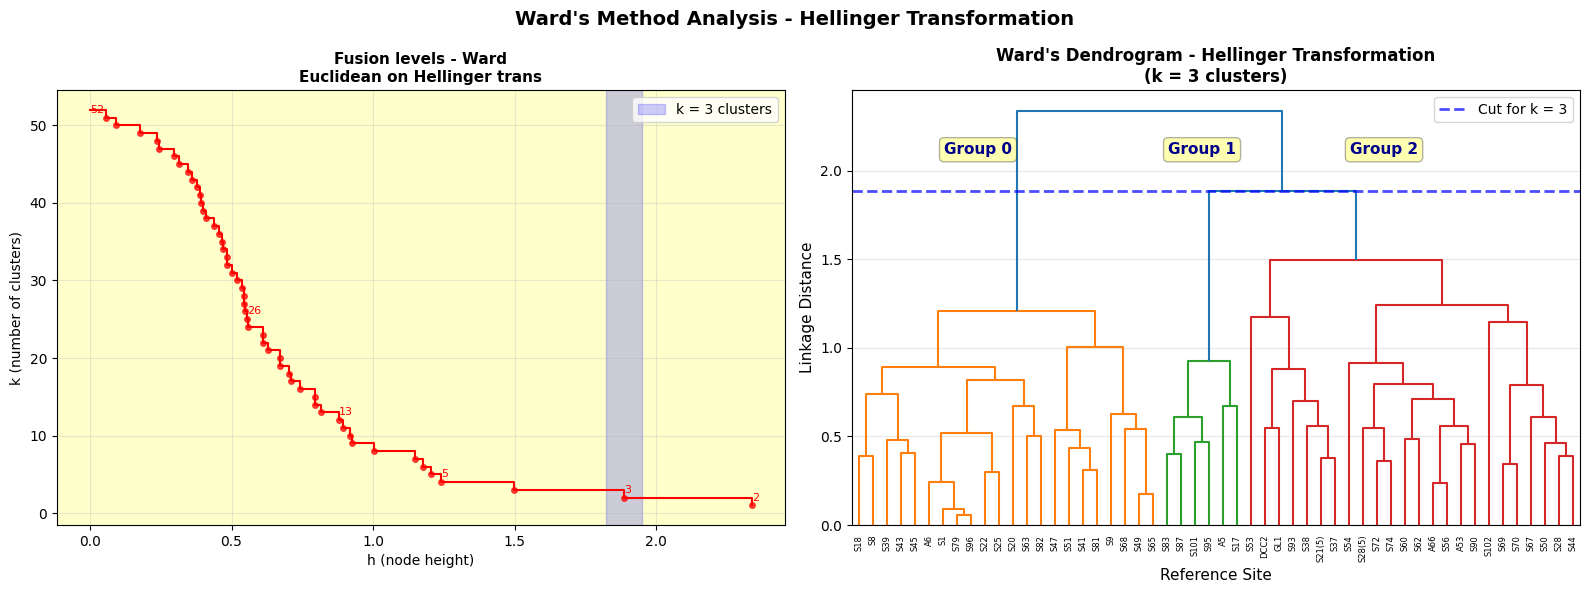

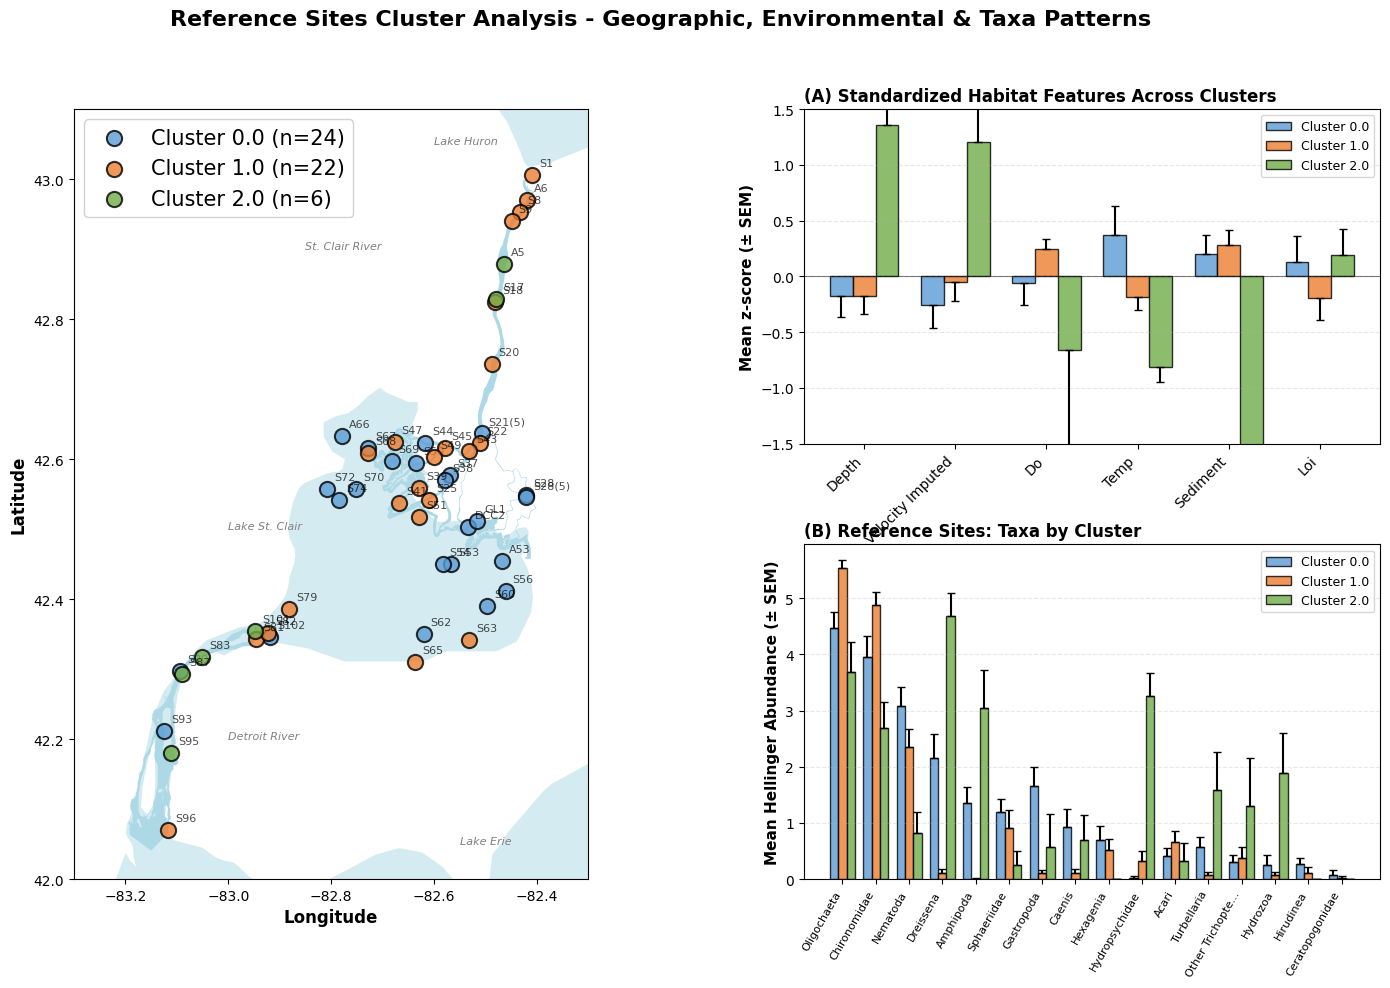

In [335]:
# =============================================================================
# STAGE 2: TAXA ASSEMBLAGE ON REFERENCE SITES
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 2: TAXA ASSEMBLAGE ON REFERENCE SITES")
print("=" * 80)

# Reload module to pick up changes
import importlib
import sys
modules_to_remove = [key for key in sys.modules.keys() if 'zci.taxa_assemblage_in_refs' in key]
for mod in modules_to_remove:
    del sys.modules[mod]

from zci.taxa_assemblage_in_refs import reference_sites_taxa_assemblage_pipeline

cfg_s2 = KEY_PARAMS['stage2']

# Determine save path
save_path_s2 = FIGURE_PATHS[2] if OUTPUT_PARAMS['save_figures'] else None
save_tables_path_s2 = TABLE_PATHS[2]

stage2_results = reference_sites_taxa_assemblage_pipeline(
    raw_data=raw_data_s1,
    multiindex_data=multiindex_data_s1,
    pollution_column=DATA_PARAMS['pollution_column'],
    # Core parameters
    reference_percentile=cfg_s2['reference_percentile'],
    species_transformation=cfg_s2['species_transformation'],
    n_clusters=cfg_s2['n_clusters'],
    top_n_taxa=cfg_s2['top_n_taxa'],
    env_variables=cfg_s2['env_variables'],
    # Visualization options
    create_cluster_visualization=cfg_s2['create_cluster_visualization'],
    create_dendrogram_comparison=cfg_s2['create_dendrogram_comparison'],
    create_ward_analysis=cfg_s2['create_ward_analysis'],
    create_comparison_plots=cfg_s2['create_comparison_plots'],
    label_positions=cfg_s2['label_positions'],
    # ANOVA options
    run_boxcox_anova=True,
    use_boxcox_transform=False,
    anova_top_n_taxa=16,
    # Save paths
    save_path=save_path_s2,
    save_tables=OUTPUT_PARAMS['save_tables'],
    table_save_path=save_tables_path_s2,
    verbose=KEY_PARAMS['verbose'],
)

# Extract outputs
raw_data_s2 = stage2_results['raw_data']
multiindex_data_s2 = stage2_results['multiindex_data']

print(f"\n✓ Stage 2 Complete!")
print(f"  - Reference sites: {(raw_data_s2['if_ref'] == True).sum()}")
print(f"  - Cluster distribution: {stage2_results['cluster_distribution']}")

# Report saved figures
if 'figures' in stage2_results and OUTPUT_PARAMS['save_figures']:
    print(f"  - Figures saved: {len(stage2_results['figures'])} to {save_path_s2}")

# Report saved tables
if 'tables' in stage2_results and OUTPUT_PARAMS['save_tables']:
    print(f"  - Tables saved: {len(stage2_results['tables'])} to {save_tables_path_s2}")

In [336]:
# =============================================================================
# DISPLAY STAGE 2 ANOVA TABLES
# =============================================================================

print("=" * 80)
print("STAGE 2 ANOVA TABLES (Box-Cox transformed)")
print("=" * 80)

if 'env_anova_table' in stage2_results and stage2_results['env_anova_table'] is not None:
    print("\n📊 ENVIRONMENTAL VARIABLES ANOVA ACROSS CLUSTERS:")
    display(stage2_results['env_anova_table'])

if 'taxa_anova_table' in stage2_results and stage2_results['taxa_anova_table'] is not None:
    print("\n🐛 TAXA ANOVA ACROSS CLUSTERS:")
    display(stage2_results['taxa_anova_table'])

STAGE 2 ANOVA TABLES (Box-Cox transformed)

📊 ENVIRONMENTAL VARIABLES ANOVA ACROSS CLUSTERS:


,Variable,Cluster 0,Cluster 1,Cluster 2,F-stat,p-value
0,Measured Depth (m),3.37 ± 2.63,3.37 ± 2.20,7.73 ± 3.27,7.89,0.001**
1,Velocity at bottom (m/sec)_Imputed,0.09 ± 0.12,0.12 ± 0.10,0.27 ± 0.12,6.26,0.004**
2,Water DO Bottom (mg/L),9.32 ± 0.97,9.63 ± 0.46,8.71 ± 2.11,2.06,0.138
3,Temperature (oC),21.13 ± 2.31,20.11 ± 0.96,18.96 ± 0.60,4.62,0.015*
4,MPS (Phi),1.36 ± 0.84,1.44 ± 0.66,-0.79 ± 1.00,20.5,0.0000***
5,LOI (%),1.86 ± 1.30,1.50 ± 1.05,1.94 ± 0.62,0.71,0.495
6,,,,,,
7,Sample size (n),24,22,6,,
8,,,,,,
9,"Significance: *** p<0.001, ** p<0.01, * p<0.05...",,,,,



🐛 TAXA ANOVA ACROSS CLUSTERS:


,Variable,Cluster 0,Cluster 1,Cluster 2,F-stat,p-value
0,Oligochaeta,4.48 ± 1.38,5.54 ± 0.65,3.70 ± 1.29,16.16,0.0000***
1,Chironomidae,3.95 ± 1.82,4.88 ± 1.05,2.69 ± 1.12,14.04,0.0000***
2,Nematoda,3.09 ± 1.67,2.35 ± 1.55,0.82 ± 0.90,5.62,0.006**
3,Dreissena,2.16 ± 2.11,0.11 ± 0.35,4.68 ± 0.99,24.75,0.0000***
4,Amphipoda,1.36 ± 1.39,0.01 ± 0.04,3.05 ± 1.66,24.0,0.0000***
5,Sphaeriidae,1.19 ± 1.13,0.91 ± 1.45,0.25 ± 0.61,2.62,0.083.
6,Gastropoda,1.65 ± 1.63,0.11 ± 0.29,0.58 ± 1.42,13.99,0.0000***
7,Caenis,0.93 ± 1.60,0.12 ± 0.28,0.69 ± 1.09,1.81,0.174
8,Hexagenia,0.70 ± 1.20,0.51 ± 0.92,0.00 ± 0.00,1.46,0.242
9,Hydropsychidae,0.02 ± 0.11,0.33 ± 0.84,3.26 ± 1.00,40.09,0.0000***


---

## Stage 3: Environment-Driven Taxa Clusters (RDA + LDA)

**Objective**: Validate that clusters correspond to distinct environmental conditions and predict clusters for non-reference sites.

**Key Parameters**:
- `rda_n_permutations`: Number of permutations for RDA significance testing
- `env_variables`: Habitat variables used for RDA and LDA
- `lda_n_iterations`: Monte Carlo cross-validation iterations for LDA


STAGE 3: ENVIRONMENT-DRIVEN TAXA CLUSTERS (RDA + LDA)

ENVIRONMENT-DRIVEN TAXA CLUSTERS ANALYSIS PIPELINE

This pipeline performs:
  1. RDA ordination analysis
  2. LDA classification with Monte Carlo CV
  3. LDA-RDA axis comparison
  4. Non-reference site prediction
  5. Data integration with complete cluster labels


STEP 1: REDUNDANCY ANALYSIS (RDA)

REDUNDANCY ANALYSIS (RDA) PIPELINE

Analyzing habitat-taxa relationships at reference sites

Step 1: Filtering reference sites...
  - Total sites: 52
  - Reference sites: 52
  - Clusters: 3

Step 2: Preparing environmental data...
  - Standardizing environmental variables (z-score)
  - Environmental variables: 6
  - Shape: (52, 6)

Step 3: Preparing taxa data...
  - Taxa transformation: Hellinger
  - Number of taxa: 16
  - Shape: (52, 16)

Step 4: Fitting RDA model...
  ✓ RDA model fitted successfully
  - R²: 0.2085
  - Adjusted R²: 0.1030
  - Constrained inertia: 3.3098
  - Residual inertia: 12.5638

Step 5: Performing permutation tes

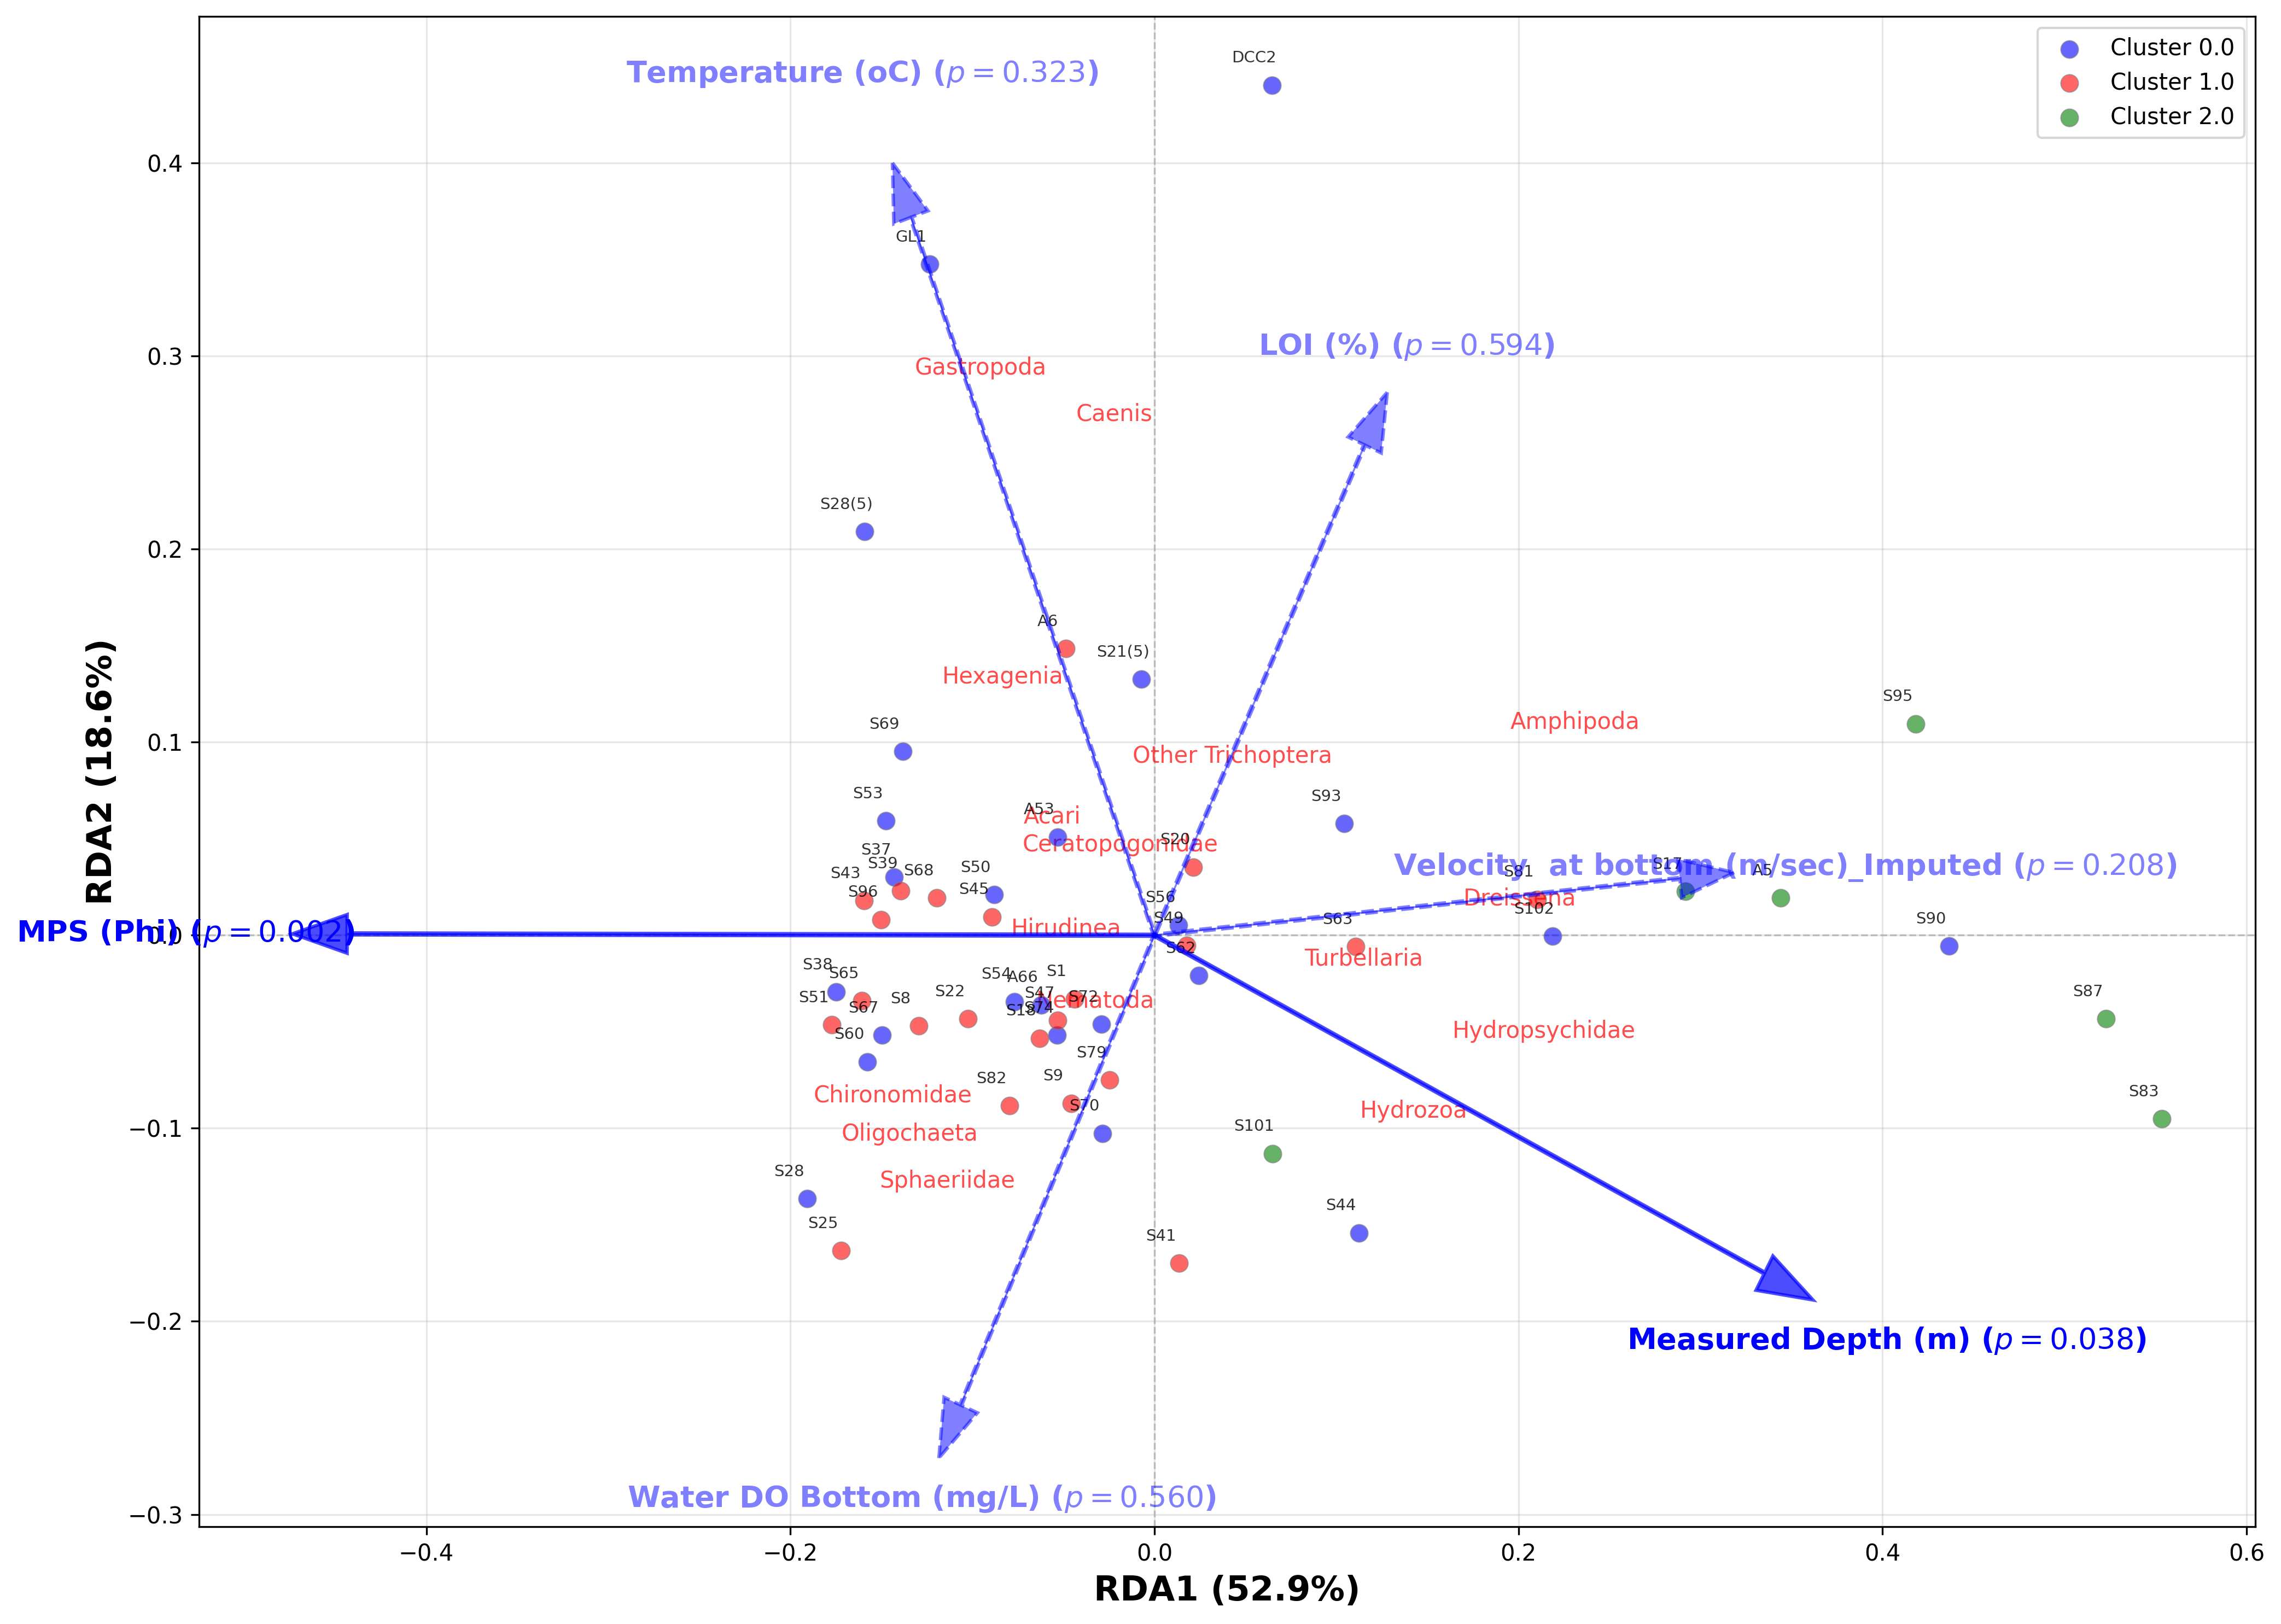

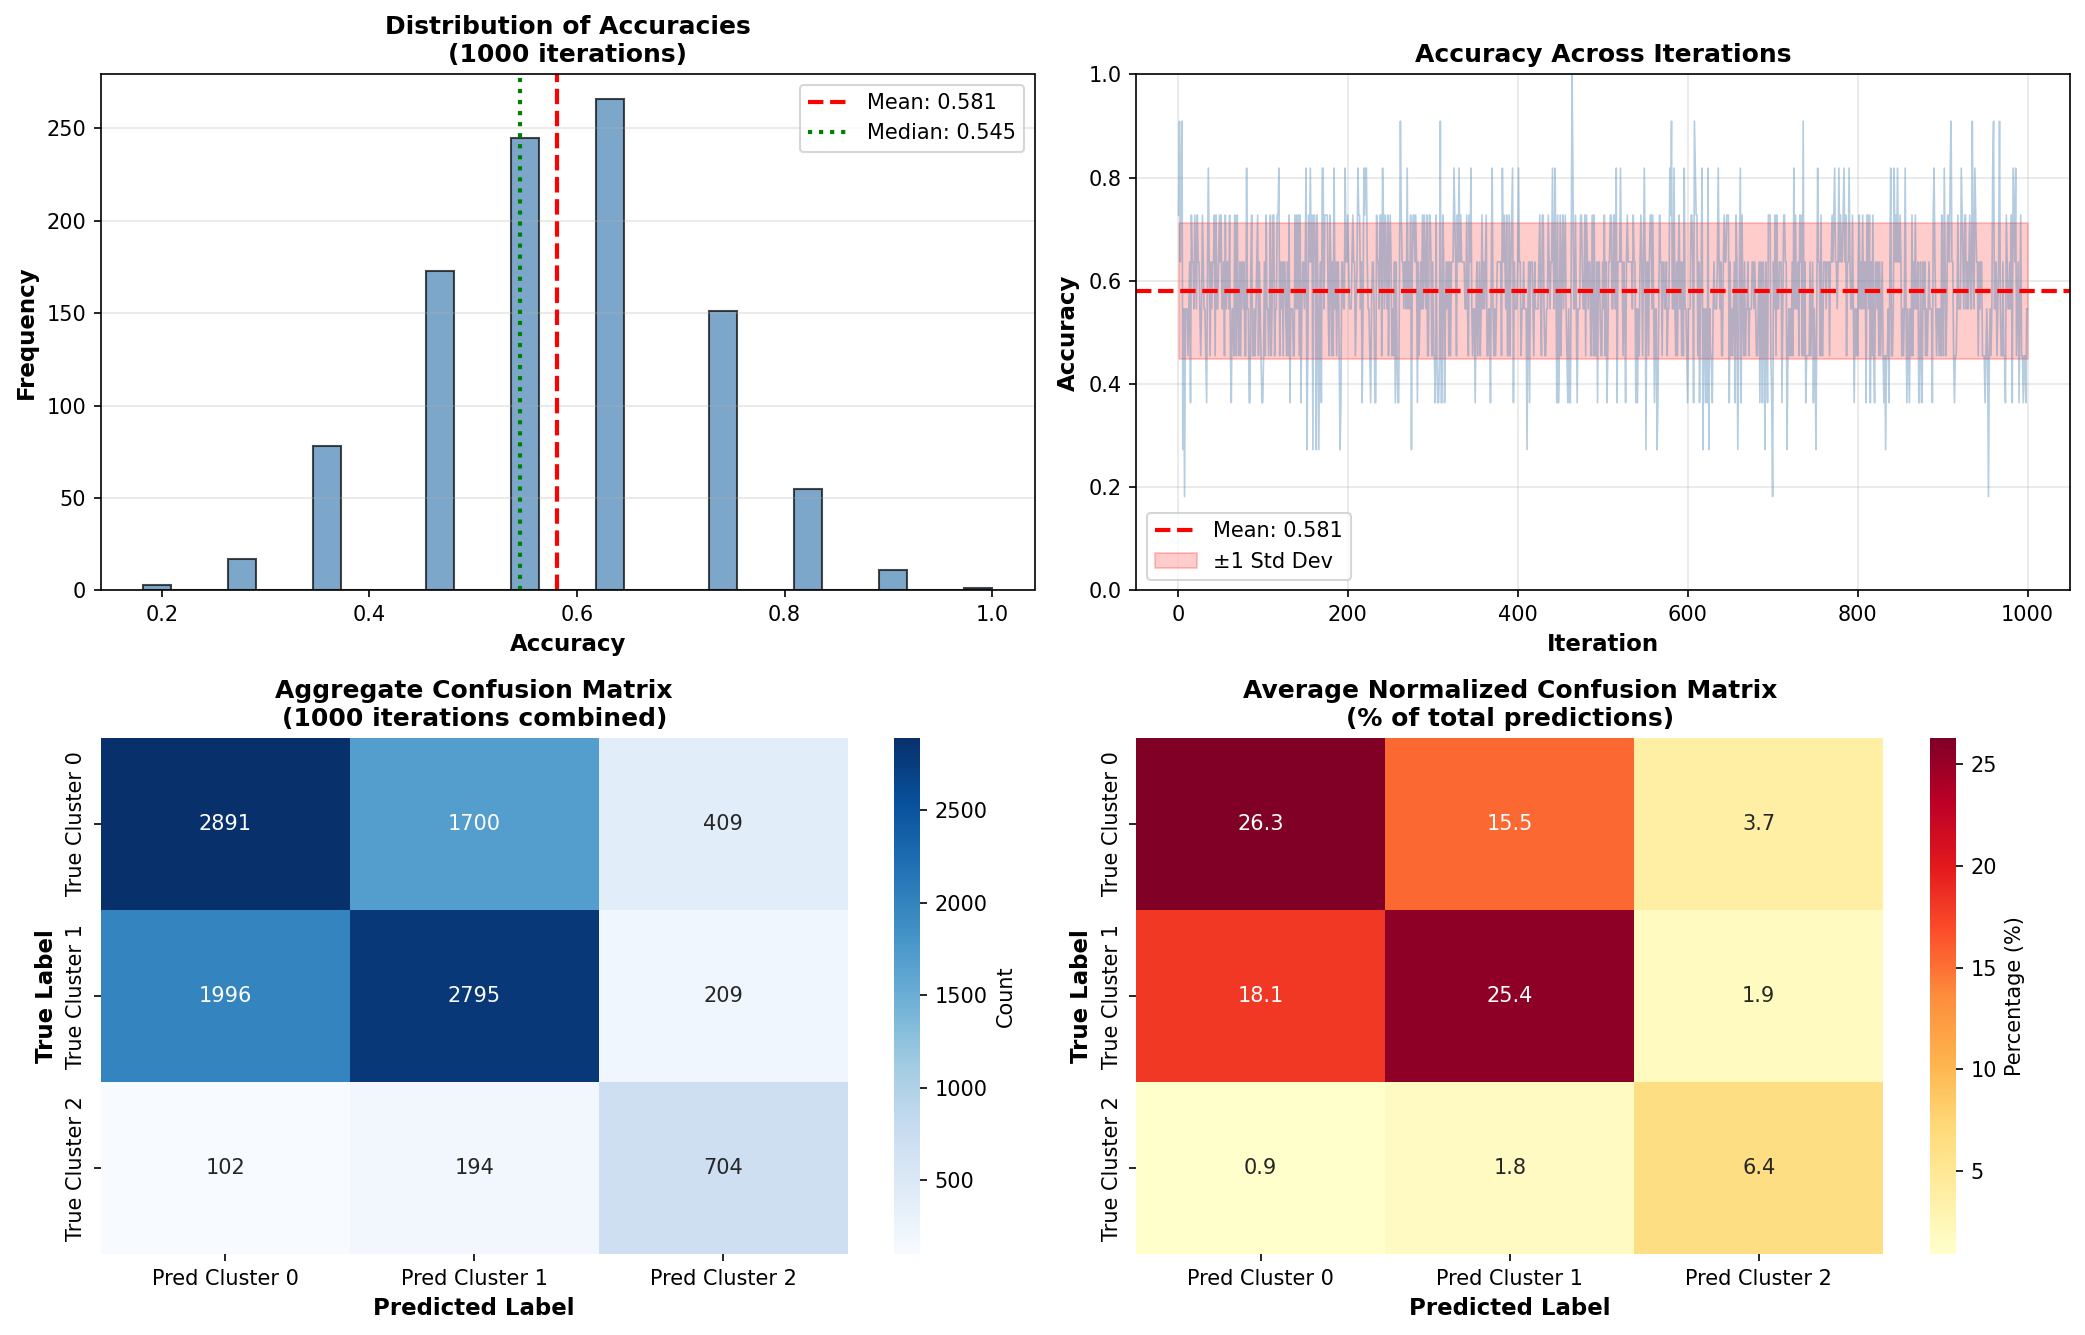

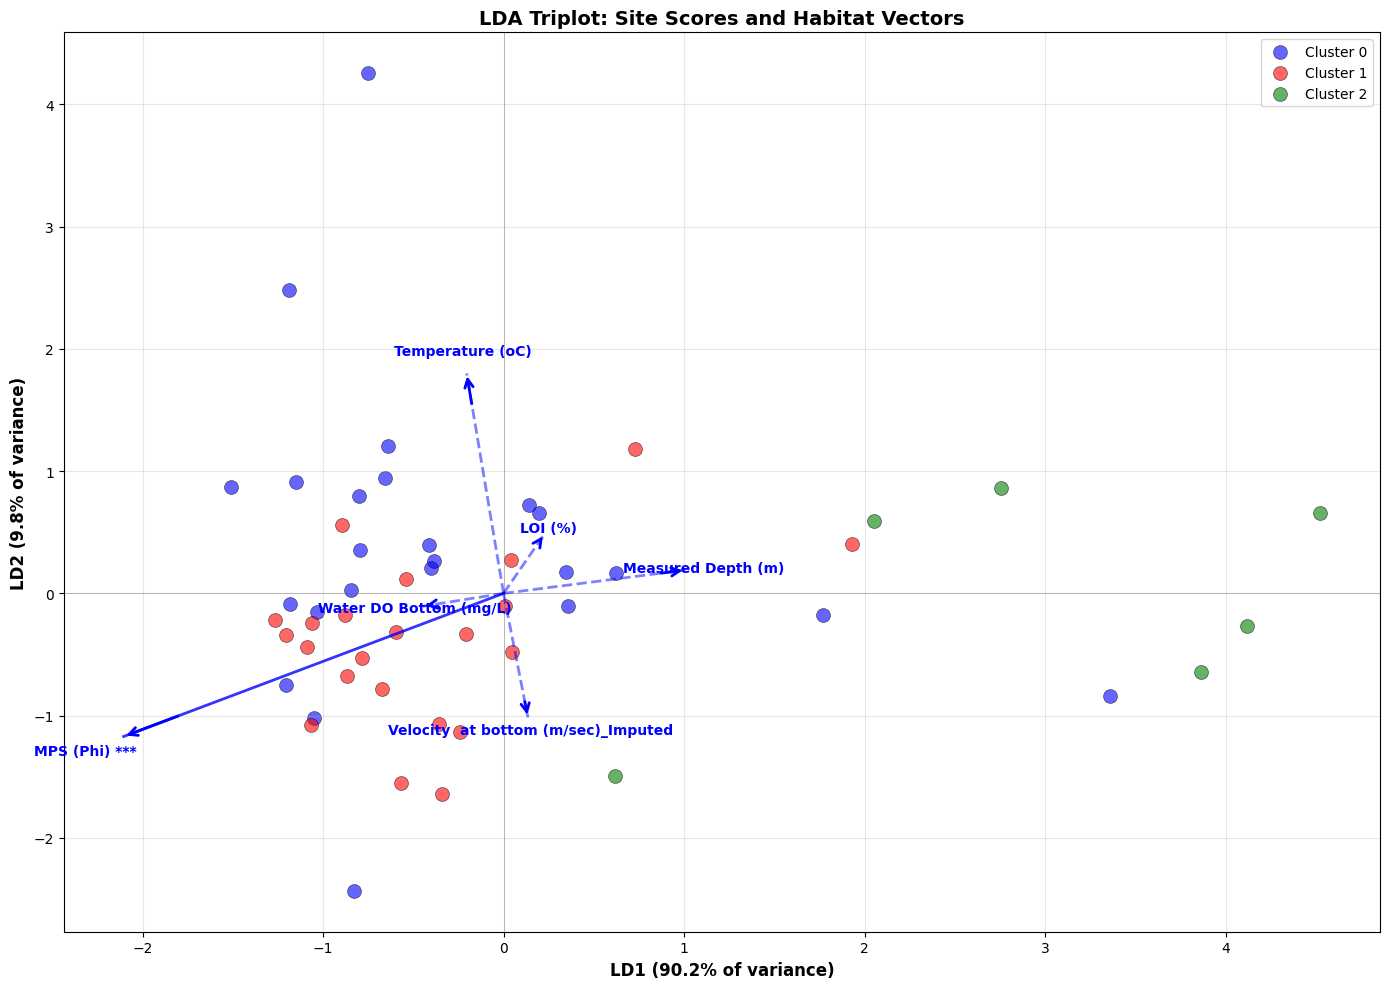

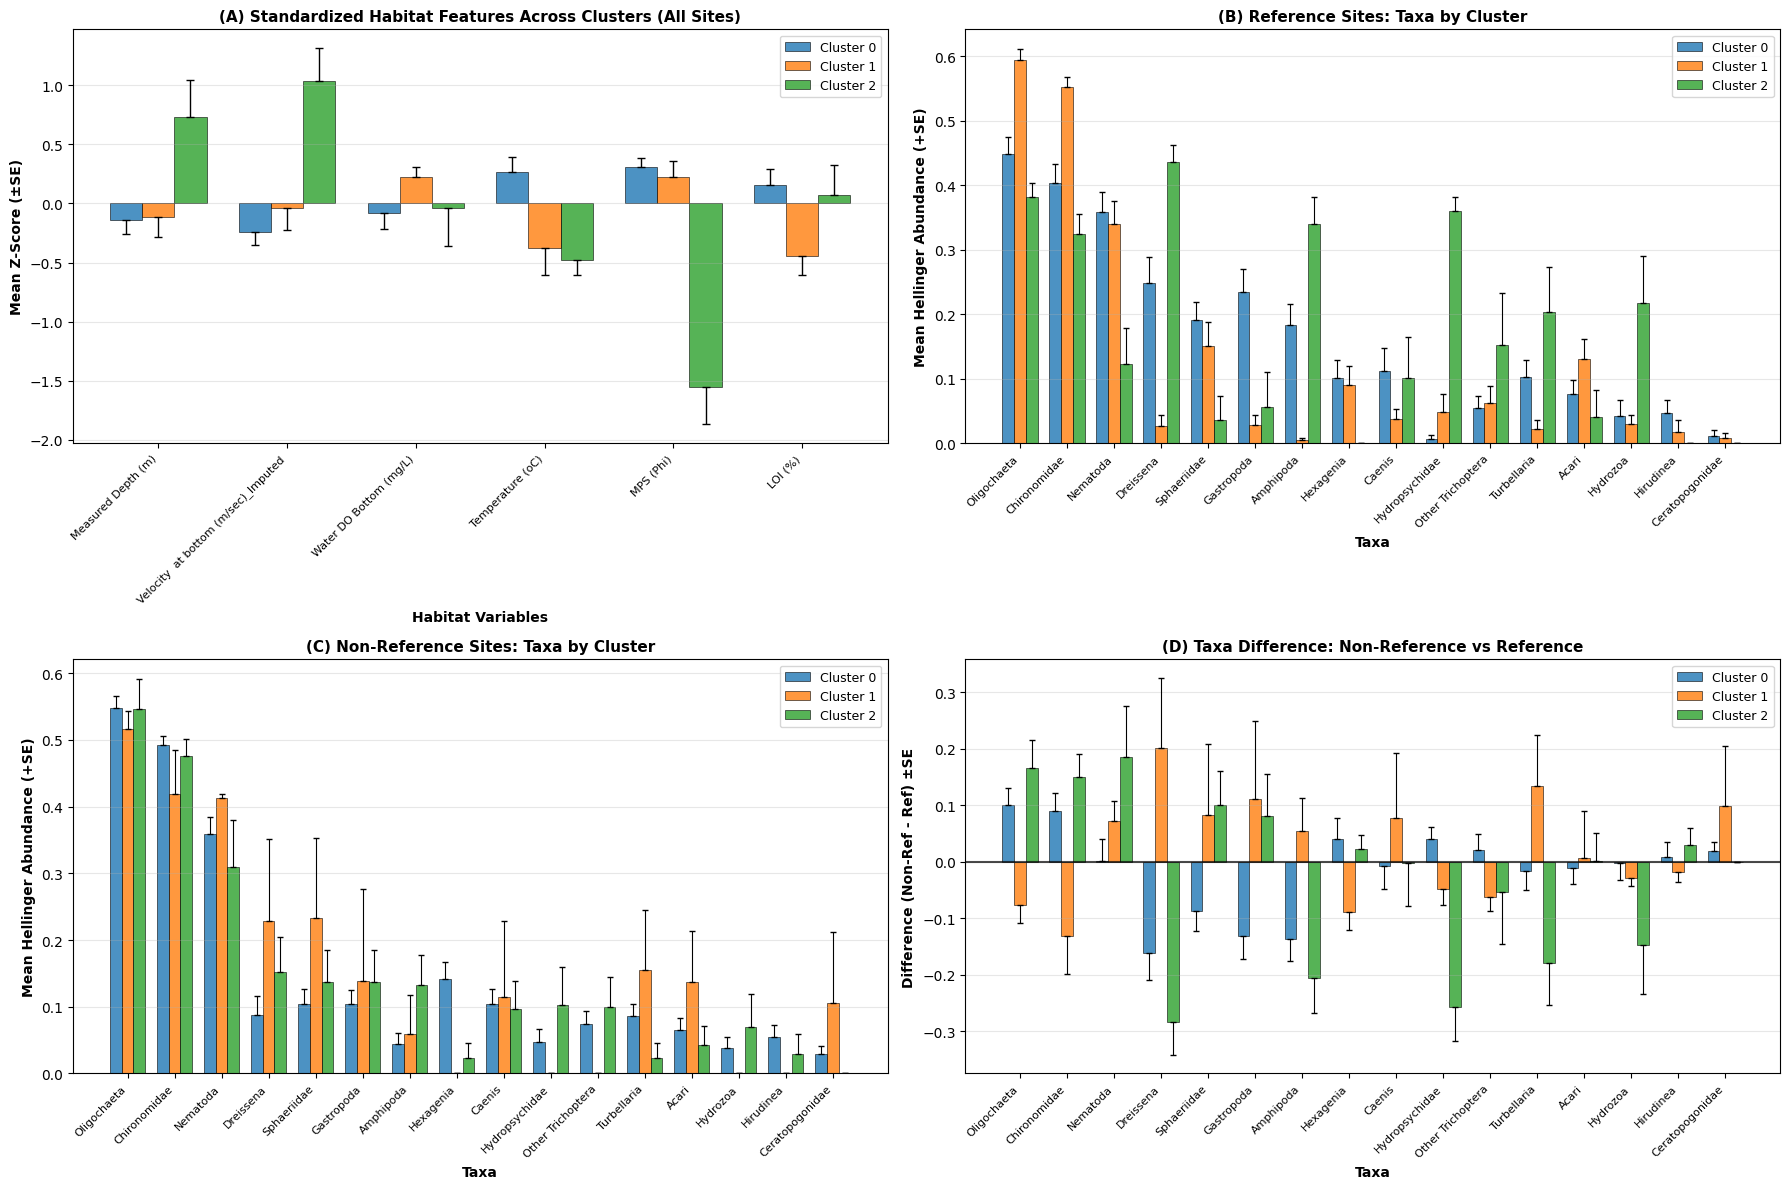

In [337]:
# =============================================================================
# STAGE 3: ENVIRONMENT-DRIVEN TAXA CLUSTERS (RDA + LDA)
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 3: ENVIRONMENT-DRIVEN TAXA CLUSTERS (RDA + LDA)")
print("=" * 80)

# Reload module to pick up changes
import importlib
import sys
modules_to_remove = [key for key in sys.modules.keys() if 'zci.env_driven_taxa_clusters' in key]
for mod in modules_to_remove:
    del sys.modules[mod]

from zci.env_driven_taxa_clusters import perform_env_taxa_analysis

cfg_s2 = KEY_PARAMS['stage2']
cfg_s3 = KEY_PARAMS['stage3']

# Determine save paths
save_path_s3 = FIGURE_PATHS[3] if OUTPUT_PARAMS['save_figures'] else None
table_save_path_s3 = TABLE_PATHS[3] if OUTPUT_PARAMS['save_tables'] else None

stage3_results = perform_env_taxa_analysis(
    raw_data=raw_data_s2,
    multiindex_data=multiindex_data_s2,
    env_variables=cfg_s2['env_variables'],          # Use same env variables from Stage 2
    cluster_column=DATA_PARAMS['cluster_column'],
    ref_column=DATA_PARAMS['ref_column'],
    # RDA parameters
    rda_log_transform_env=cfg_s3['rda_log_transform_env'],
    rda_standardize_env=cfg_s3['rda_standardize_env'],
    taxa_transformation=cfg_s3['taxa_transformation'],
    top_n_taxa=cfg_s3['top_n_taxa_rda'],
    rda_n_permutations=cfg_s3['rda_n_permutations'],
    # LDA parameters
    lda_log_transform_env=cfg_s3['lda_log_transform_env'],
    lda_standardize_env=cfg_s3['lda_standardize_env'],
    lda_n_iterations=cfg_s3['lda_n_iterations'],
    lda_test_size=cfg_s3['lda_test_size'],
    # Visualization parameters
    rda_arrow_scale=cfg_s3['rda_arrow_scale'],
    rda_species_scale=cfg_s3['rda_species_scale'],
    rda_figsize=cfg_s3['rda_figsize'],
    lda_cv_figsize=cfg_s3['lda_cv_figsize'],
    lda_arrow_scale=cfg_s3['lda_arrow_scale'],
    # Control
    random_state=cfg_s3['random_state'],
    save_path=save_path_s3,
    save_tables=OUTPUT_PARAMS['save_tables'],
    table_save_path=table_save_path_s3,
    verbose=KEY_PARAMS['verbose'],
)

# Extract outputs (clusters now assigned to all sites)
raw_data_s3 = stage3_results['updated_raw_data']
multiindex_data_s3 = stage3_results['updated_multiindex_data']

print(f"\n✓ Stage 3 Complete!")
print(f"  - RDA R²: {stage3_results['rda_results']['rda_model'].fit_.r2:.3f}")
print(f"  - RDA Global Test p-value: {stage3_results['rda_results']['global_test'].p_value:.4f}")
print(f"  - LDA Full Model Accuracy: {stage3_results['lda_results']['accuracy']:.2%}")
print(f"  - LDA CV Mean Accuracy: {stage3_results['lda_cv_results']['mean_accuracy']:.2%} ± {stage3_results['lda_cv_results']['std_accuracy']:.2%}")

# Report saved figures
if 'figures' in stage3_results and OUTPUT_PARAMS['save_figures']:
    print(f"  - Figures saved: {len(stage3_results['figures'])} to {save_path_s3}")

# Report saved tables
if 'tables' in stage3_results and OUTPUT_PARAMS['save_tables']:
    print(f"  - Tables saved: {len(stage3_results['tables'])} to {table_save_path_s3}")

In [338]:
# Reload module to pick up changes
import importlib
import sys

# Remove cached modules
modules_to_remove = [key for key in sys.modules.keys() if 'zci' in key]
for mod in modules_to_remove:
    del sys.modules[mod]

# Now reimport
from zci.community_composition_measures import community_composition_pipeline
print("✓ Reloaded community_composition_pipeline module")
print(f"  - Function signature has 'create_pollution_vs_species_pc_plot': {'create_pollution_vs_species_pc_plot' in community_composition_pipeline.__code__.co_varnames}")

✓ Reloaded community_composition_pipeline module
  - Function signature has 'create_pollution_vs_species_pc_plot': True



STAGE 4: COMMUNITY COMPOSITION ORDINATION (PCA-based ZCI)
COMMUNITY COMPOSITION ANALYSIS PIPELINE

Configuration:
  Taxa transformation: hellinger
  Training percentile: 100%
  Variance threshold: 70%
  ZCI method: least_pollution_threshold

BLOCK 1: PCA ANALYSIS
Taxa transformation: hellinger
Training percentile: 100%
Variance threshold: 70%

--- Extracting taxa data ---
Taxa data shape: (104, 16)

--- Selecting training sites ---
Using all sites for PCA training (percentile=100)

--- Fitting PCA models ---
FITTING PCA MODELS FOR EACH CLUSTER
Taxa transformation: hellinger
Variance threshold: 70%
Number of clusters: 3

--- Cluster 0 ---
  Training sites: 63
  Number of species: 16
  Number of PCs: 7
  Variance explained:
    PC1: 19.52%
    PC2: 16.20%
    PC3: 9.63%
  Total variance: 74.67%

--- Cluster 1 ---
  Training sites: 25
  Number of species: 16
  Number of PCs: 5
  Variance explained:
    PC1: 20.68%
    PC2: 18.16%
    PC3: 14.43%
  Total variance: 74.68%

--- Cluster 2 --

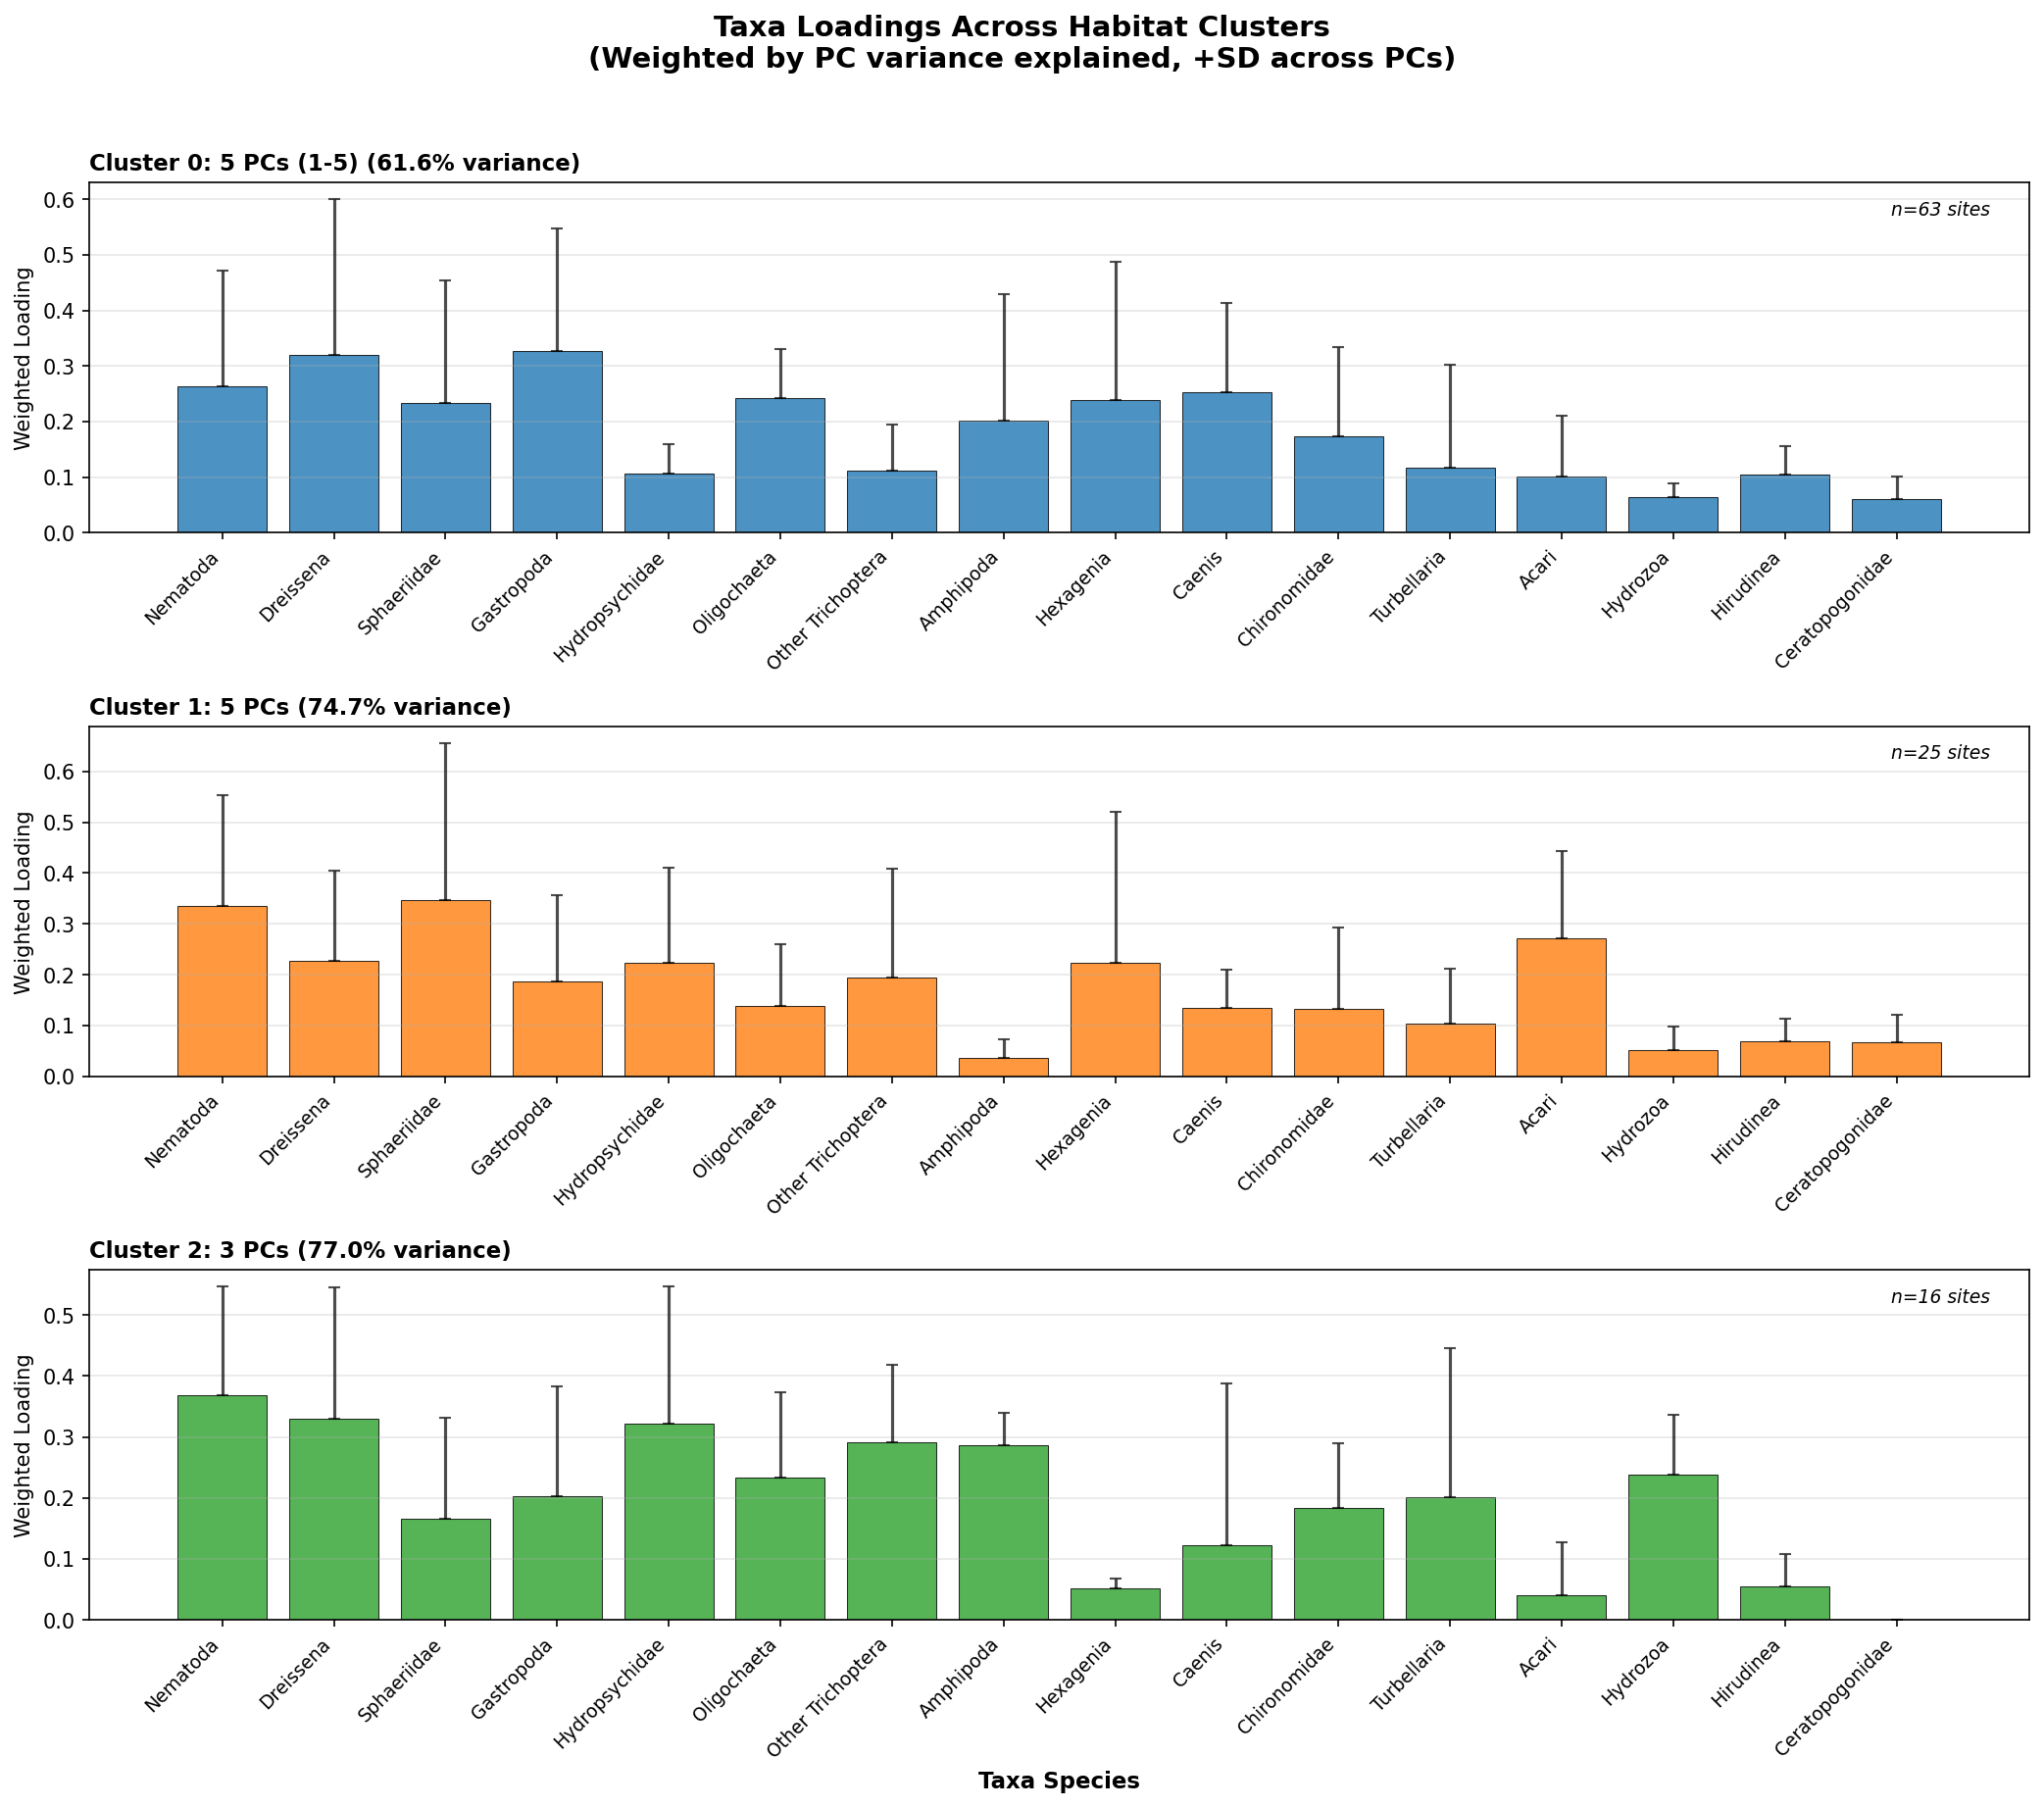

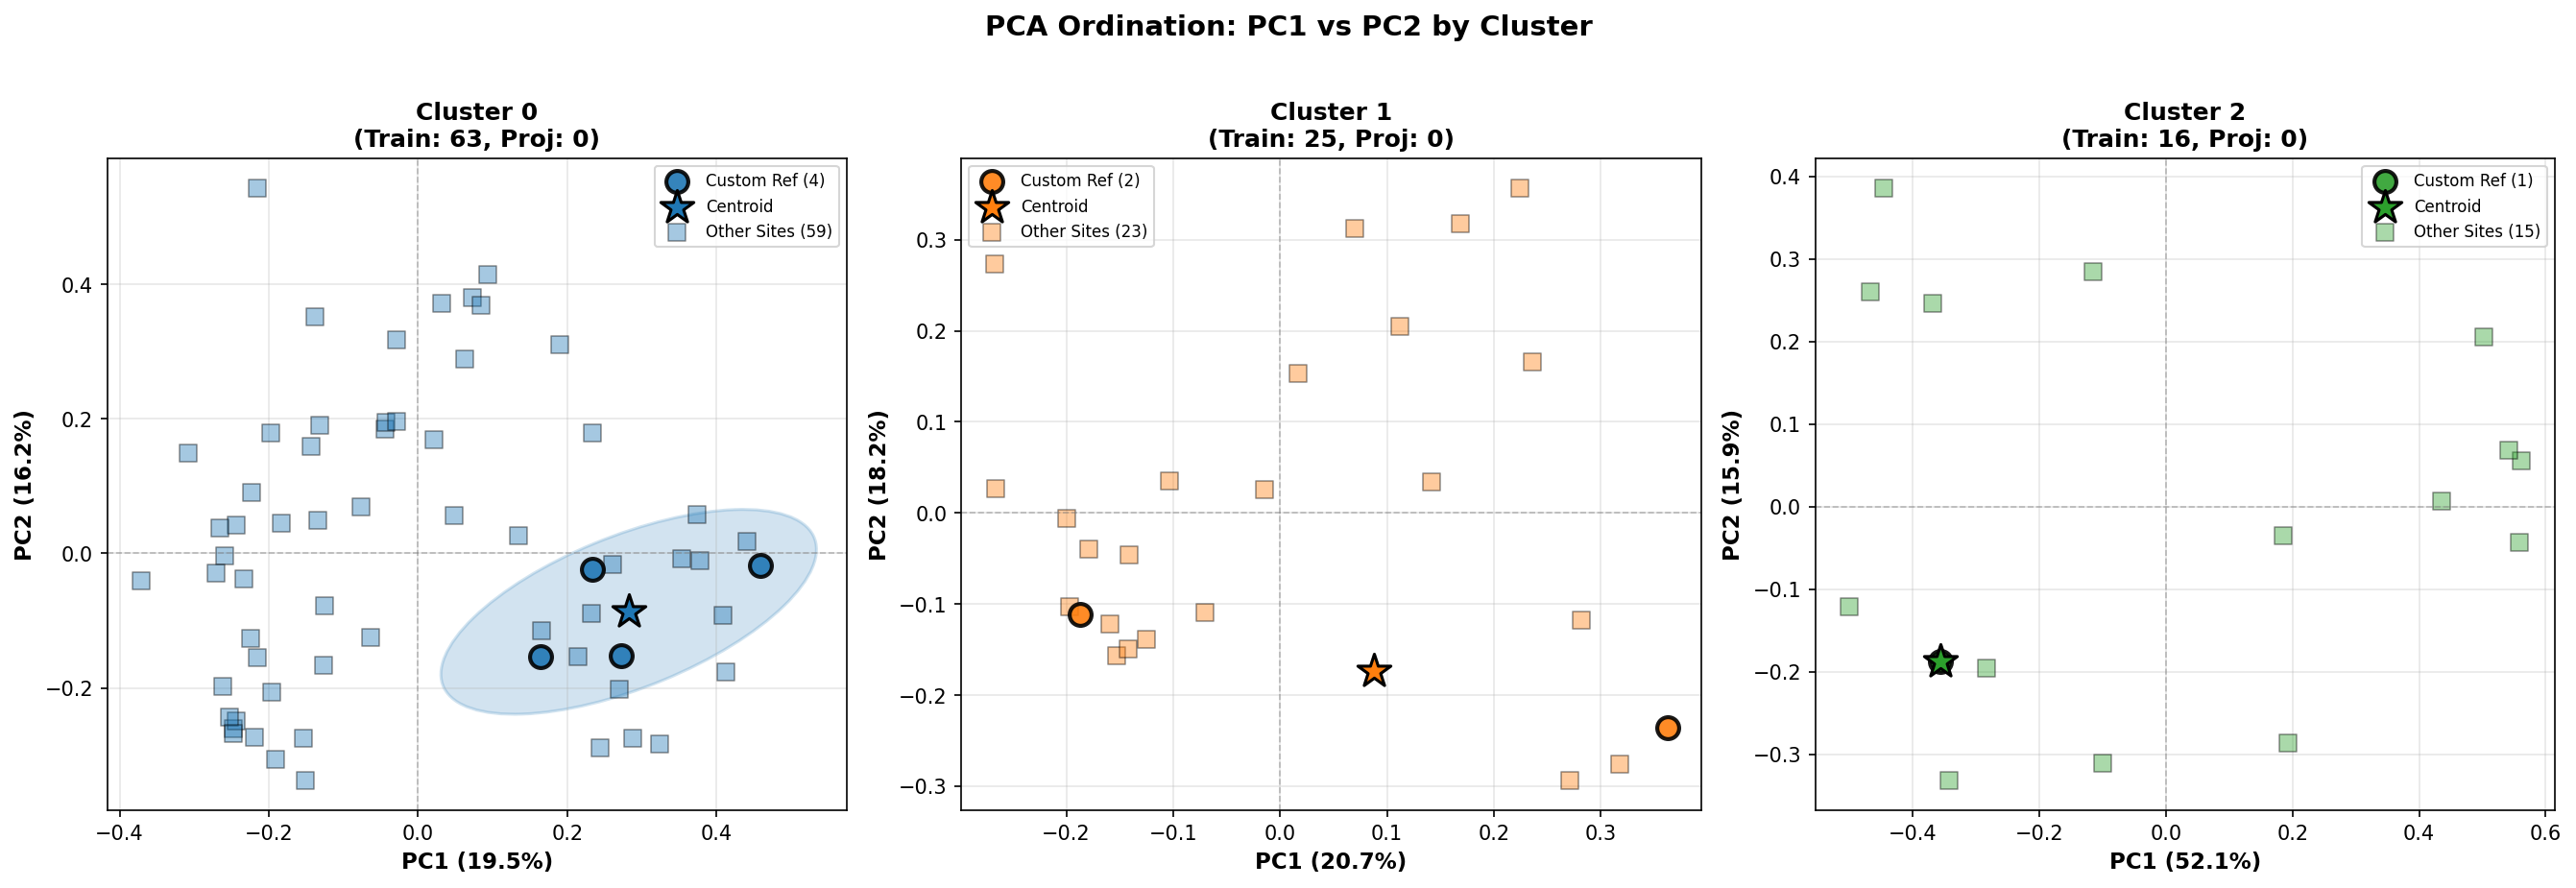

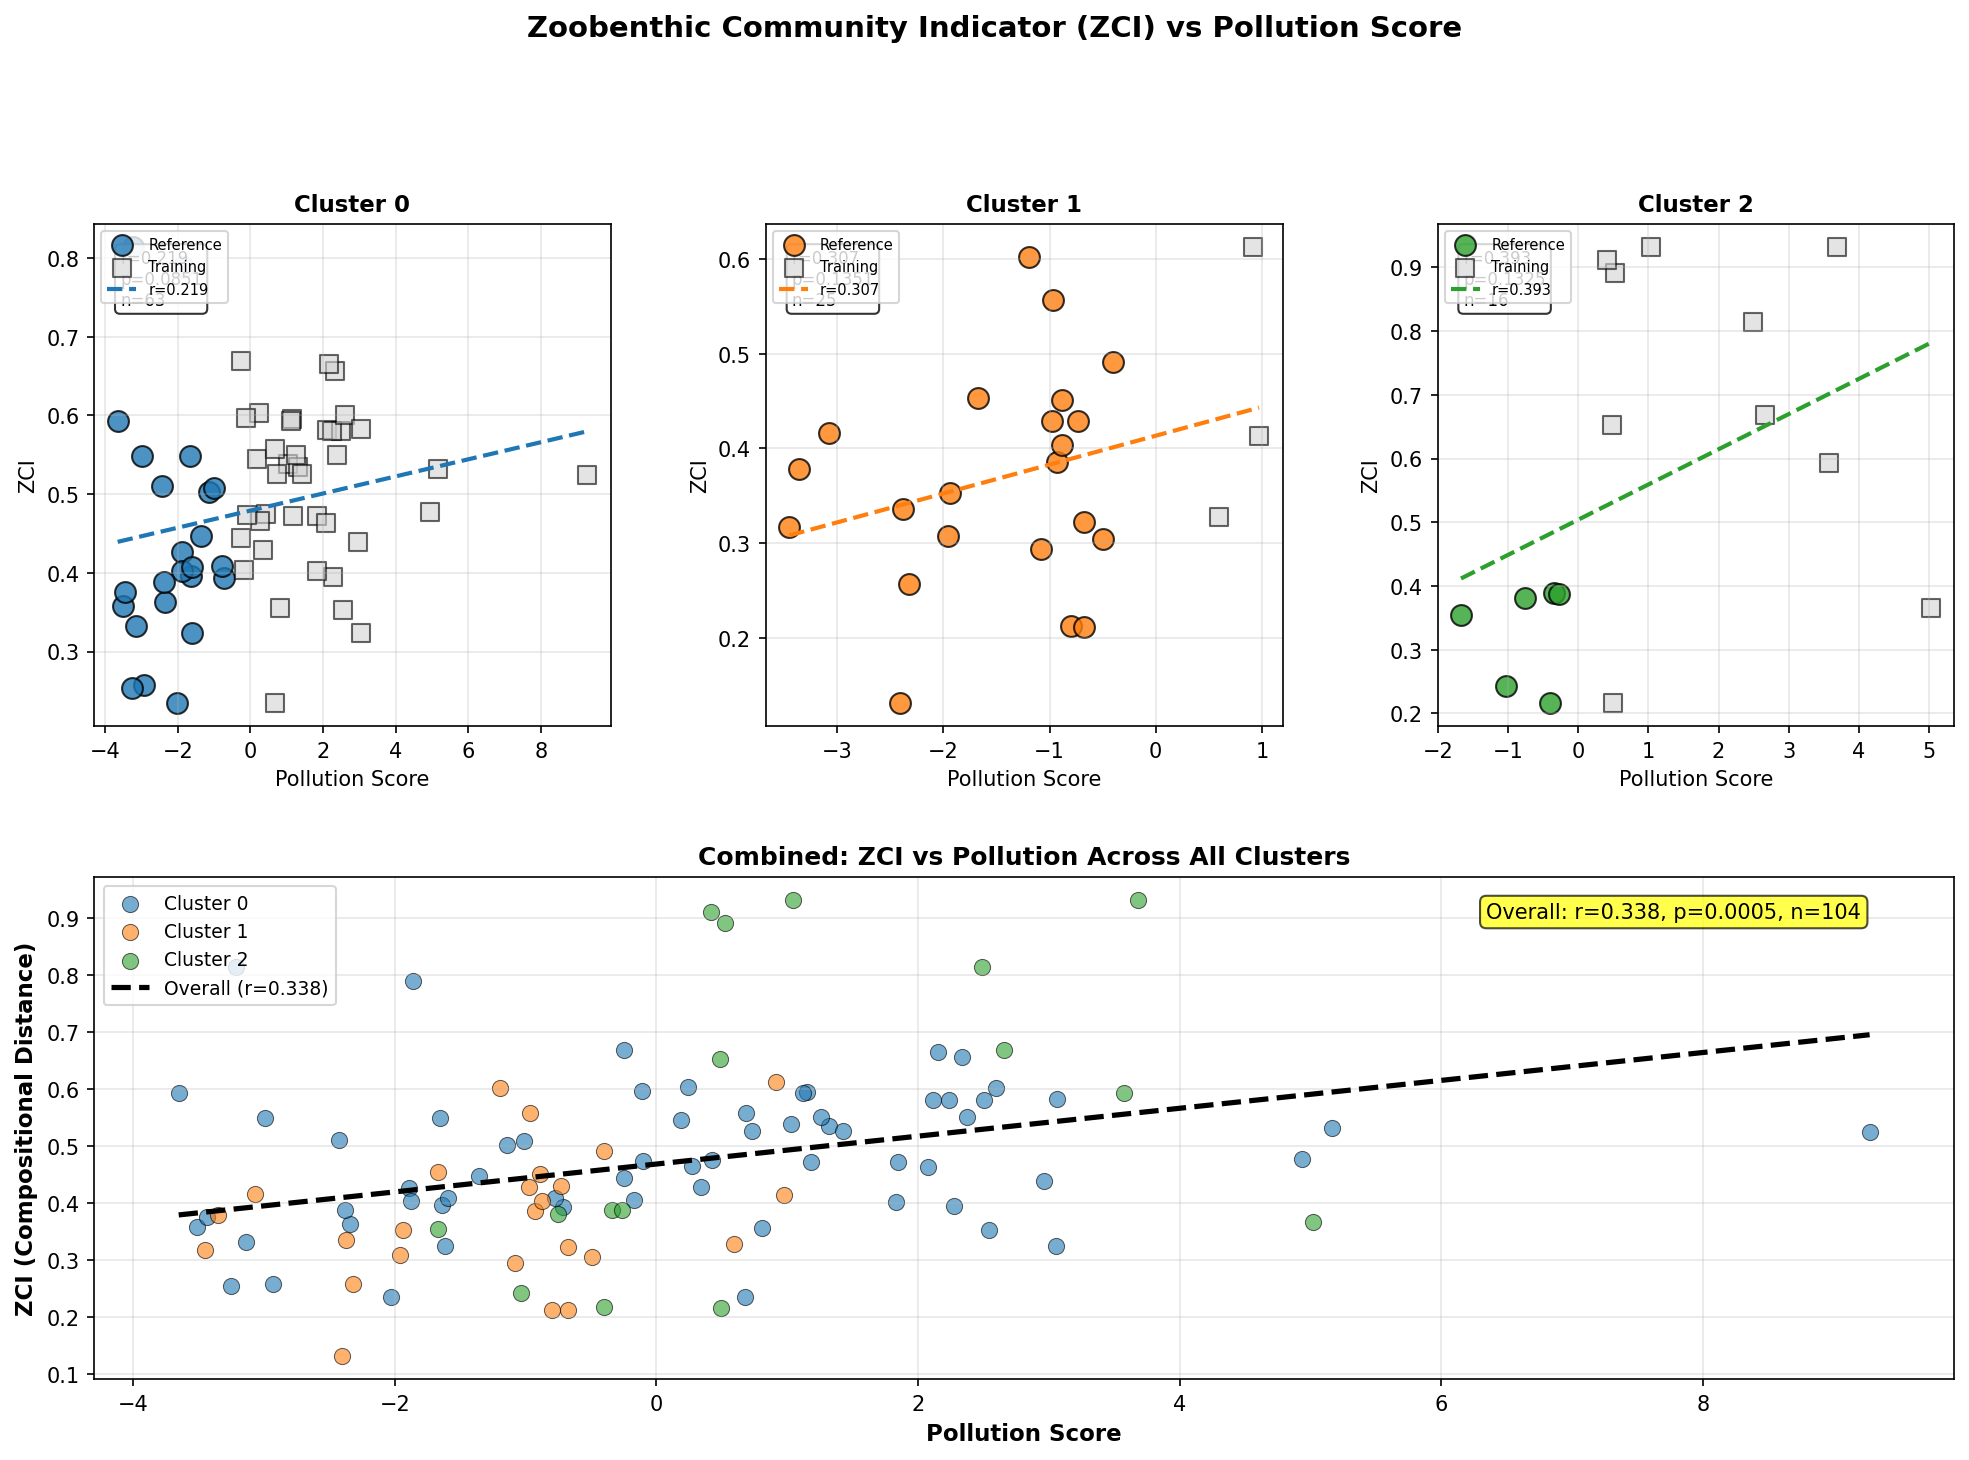

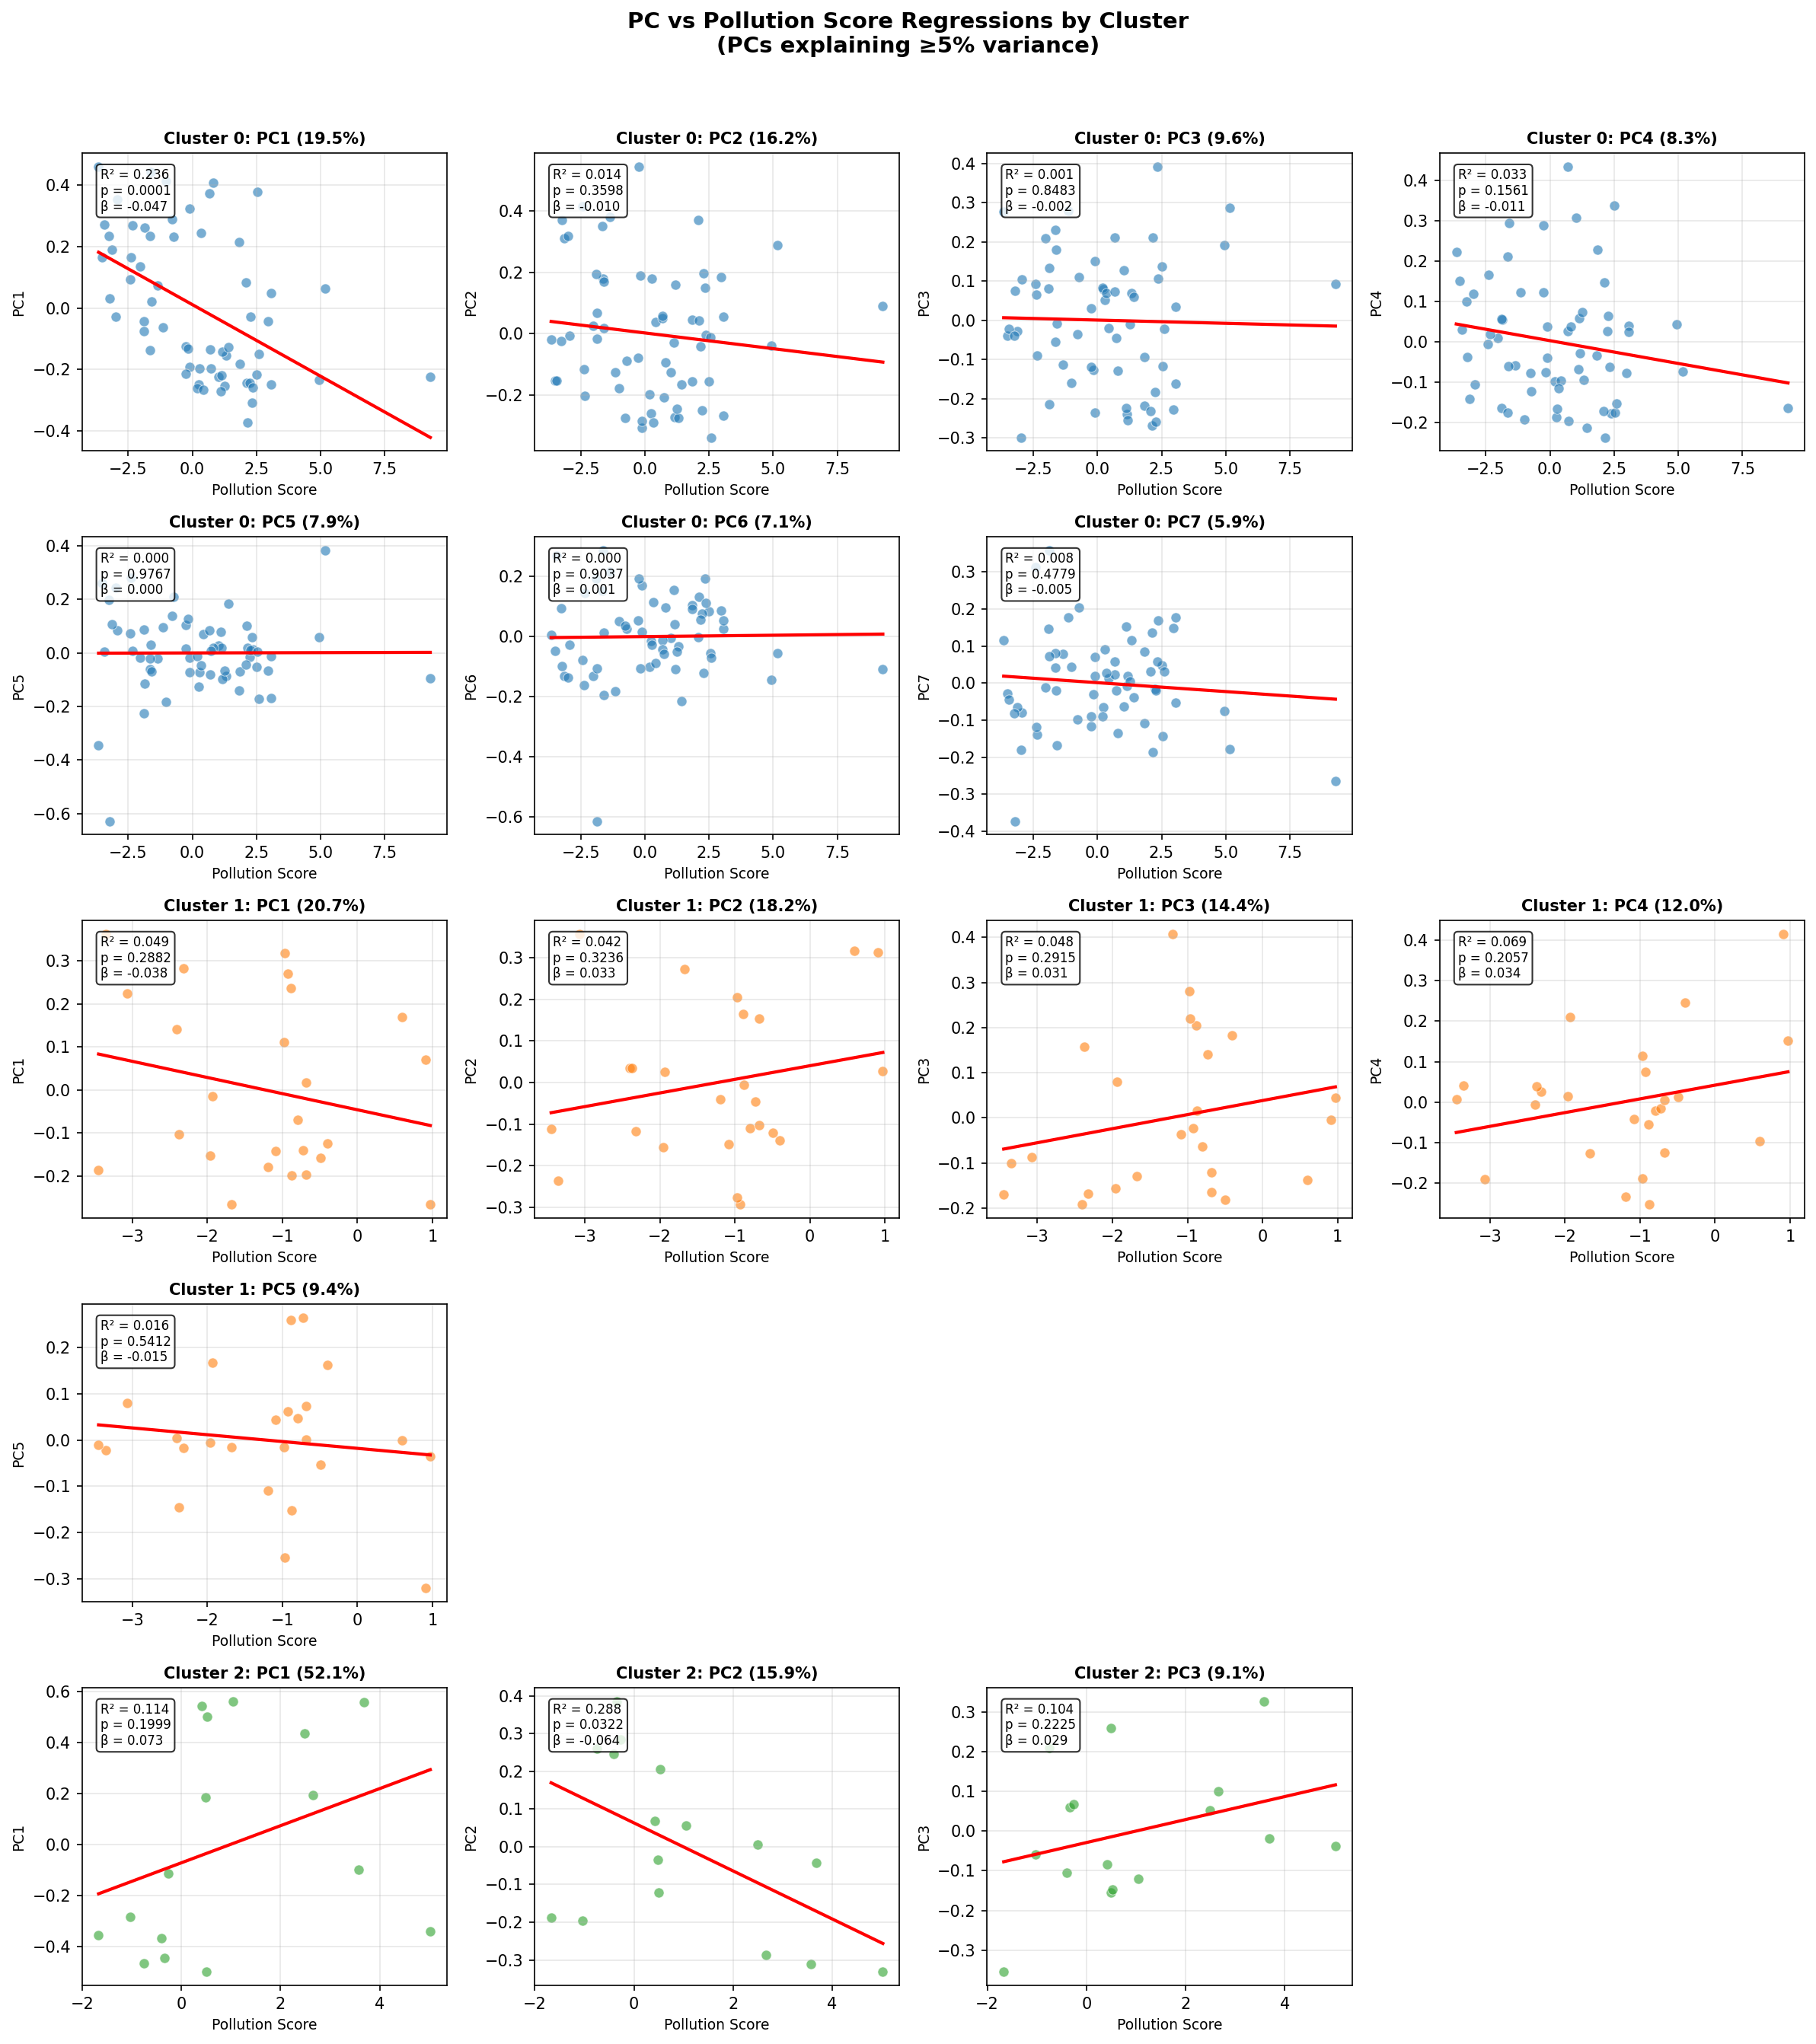

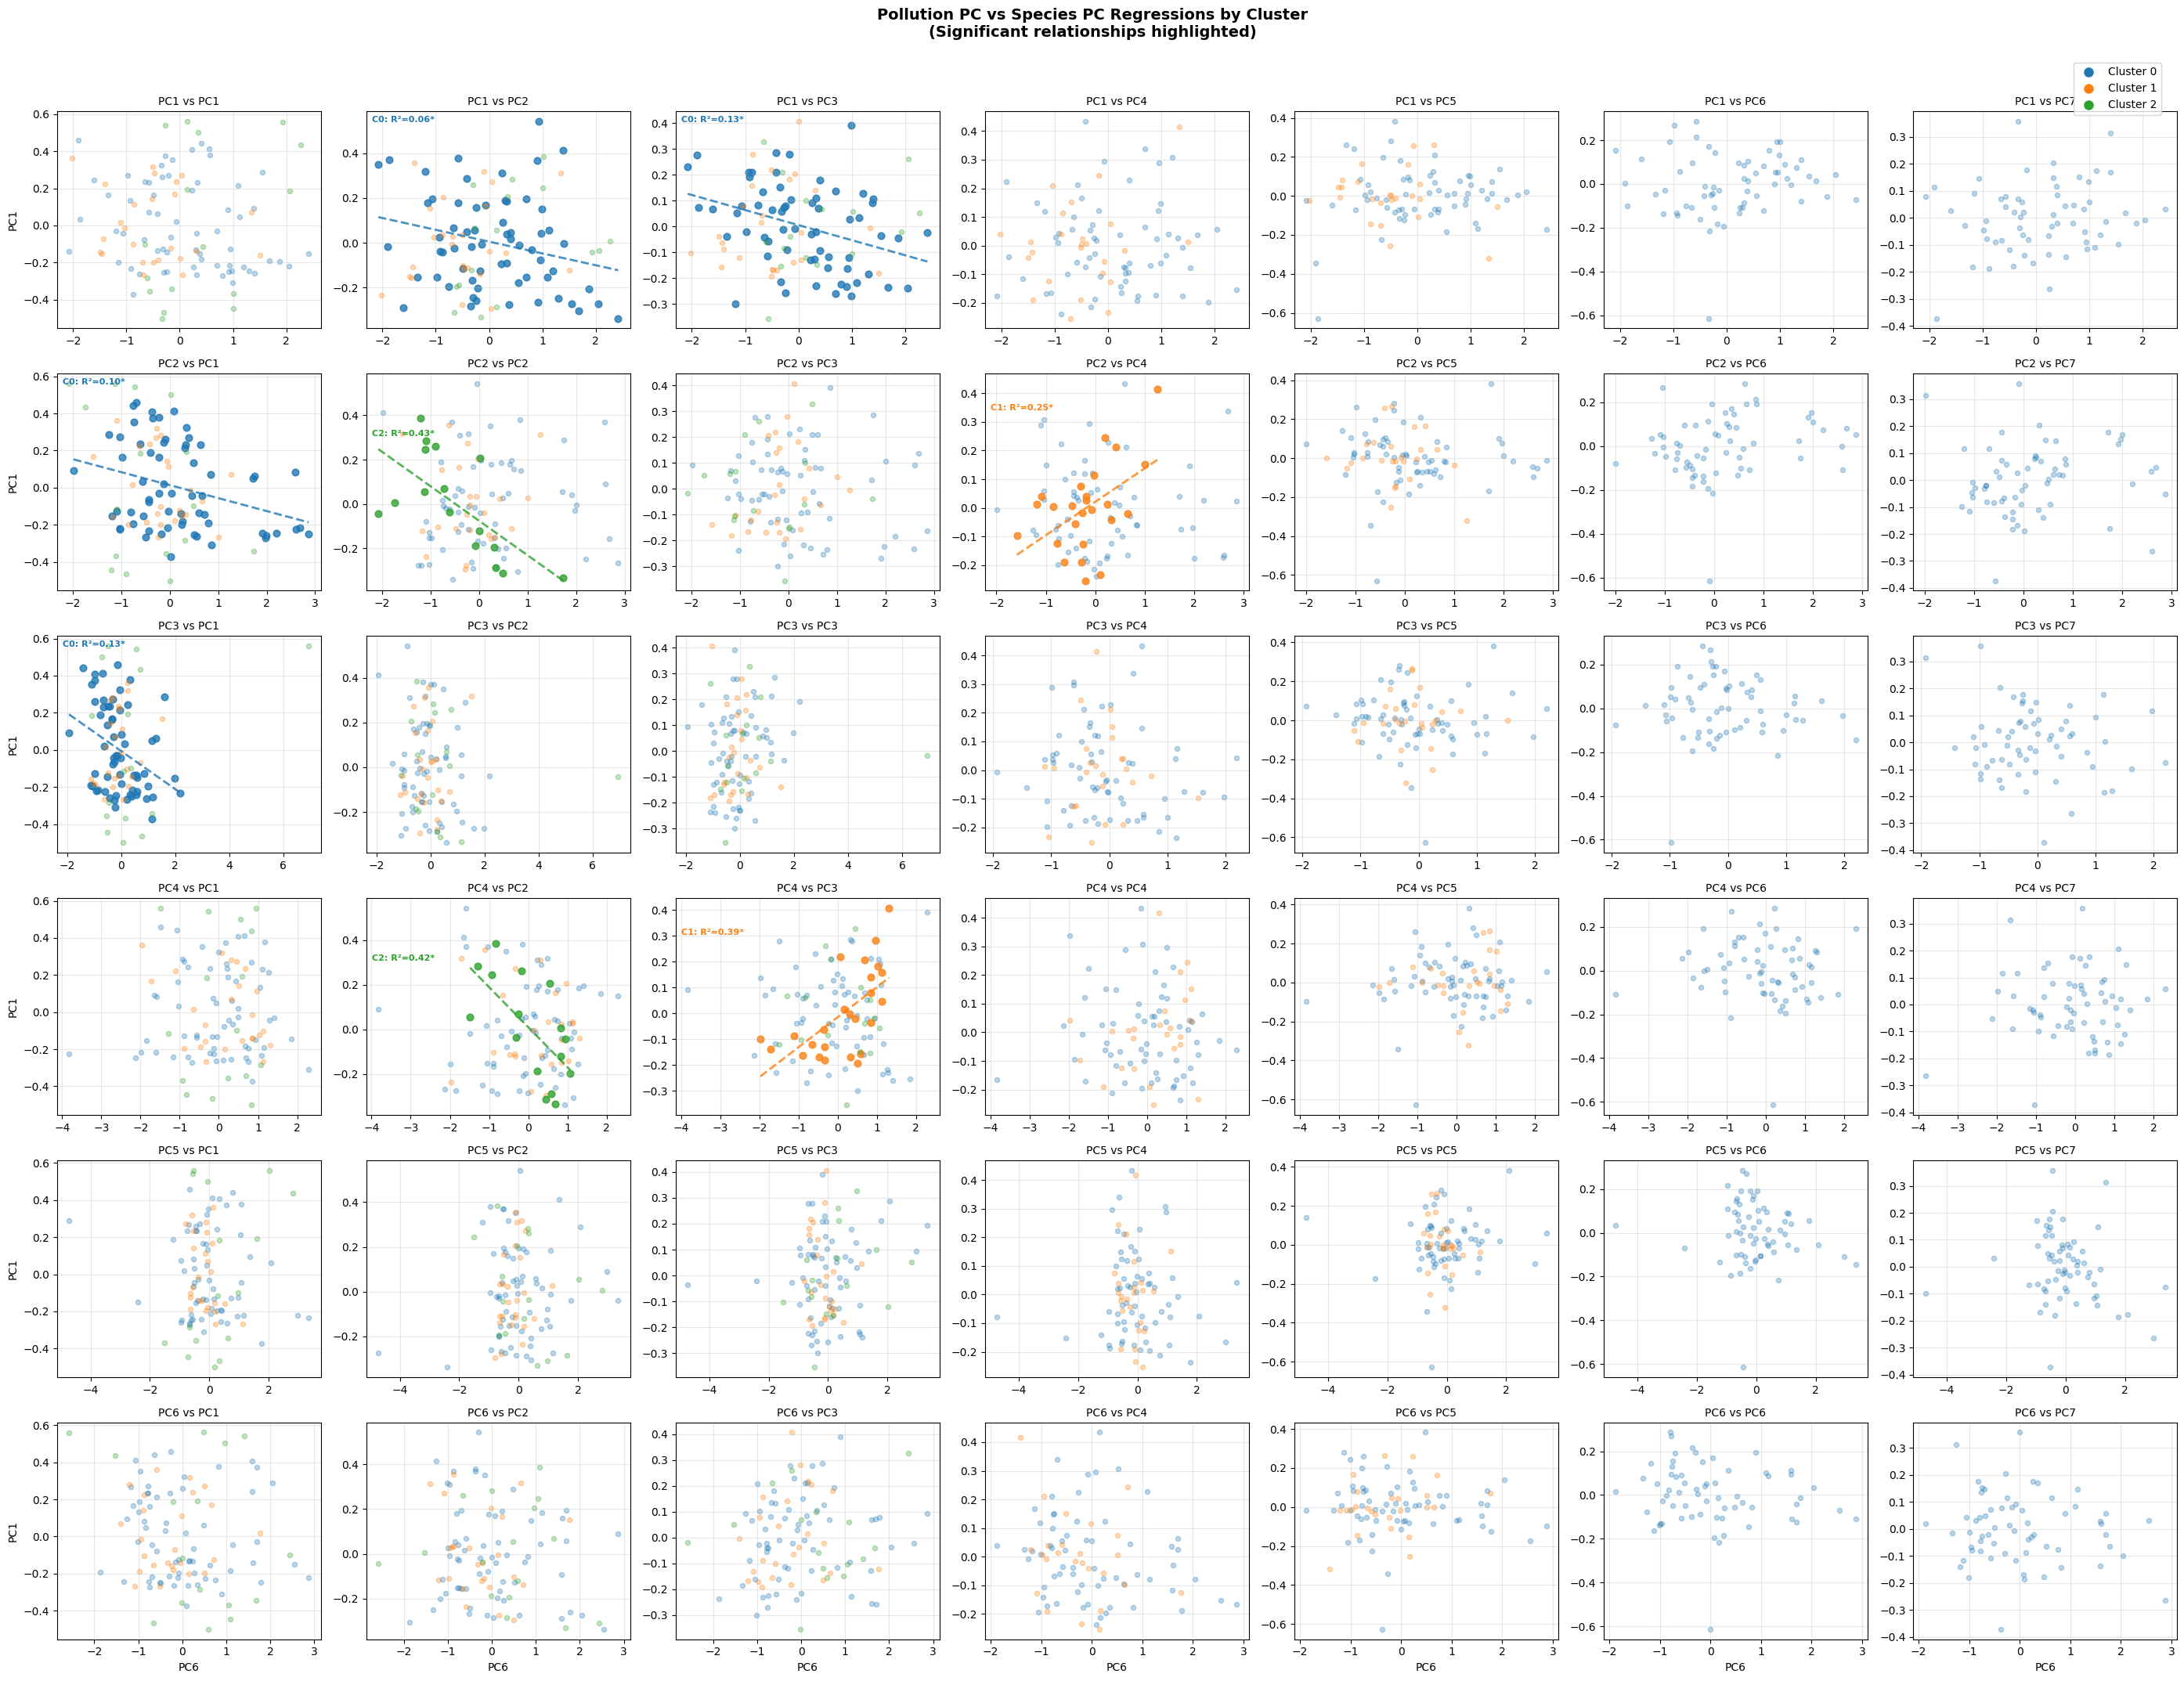

In [339]:
# =============================================================================
# STAGE 4: COMMUNITY COMPOSITION ORDINATION (PCA-based ZCI)
# =============================================================================

print("\n" + "=" * 80)
print("STAGE 4: COMMUNITY COMPOSITION ORDINATION (PCA-based ZCI)")
print("=" * 80)

cfg_s4 = KEY_PARAMS['stage4']

# Determine save path
save_path_s4 = FIGURE_PATHS[4] if OUTPUT_PARAMS['save_figures'] else None
table_save_path_s4 = TABLE_PATHS[4] if OUTPUT_PARAMS['save_tables'] else None

# Define custom reference sites (e.g., sites with lowest 15% pollution in each cluster)
# Define custom reference sites (lowest 15% pollution in each cluster)
custom_reference_sites = {}
for cluster_id in raw_data_s3['clusters'].unique():
    cluster_data = raw_data_s3[raw_data_s3['clusters'] == cluster_id]
    percentile = cluster_data['Pollution_Score'].quantile(0.05)
    ref_sites = cluster_data[cluster_data['Pollution_Score'] <= percentile].index.tolist()
    custom_reference_sites[cluster_id] = ref_sites

# Run the refactored pipeline with simplified parameters
stage4_results = community_composition_pipeline(
    raw_data=raw_data_s3,
    multiindex_data=multiindex_data_s3,
    cluster_column=DATA_PARAMS['cluster_column'],
    ref_column=DATA_PARAMS['ref_column'],
    pollution_column=DATA_PARAMS['pollution_column'],
    
    # --- PCA PARAMETERS ---
    training_percentile=100,
    variance_threshold=cfg_s4['variance_threshold'],
    taxa_transformation=cfg_s4['taxa_transformation'],
    
    # --- ZCI PARAMETERS ---
    zci_method=cfg_s4['zci_method'],
    least_pollution_threshold=20,
    zci_pc_planes=None,
    normalize_pcs=cfg_s4['normalize_pcs'],
    
    # --- REGRESSION PARAMETERS ---
    pc_variance_threshold=cfg_s4['pc_variance_threshold'],
    pollution_pc_prefix=cfg_s4['pollution_pc_prefix'],
    
    # --- VISUALIZATION PARAMETERS ---
    create_taxa_loadings_plot=cfg_s4['create_taxa_loadings_plot'],
    create_pc_loadings_plot=cfg_s4['create_pc_loadings_plot'],
    create_ordination_plot=cfg_s4['create_ordination_plot'],
    create_zci_plot=cfg_s4['create_zci_plot'],
    create_pc_regression_plot=cfg_s4['create_pc_regression_plot'],
    create_pollution_vs_species_pc_plot=cfg_s4['create_pollution_vs_species_pc_plot'],
    create_comprehensive_plot=cfg_s4['create_comprehensive_plot'],
    use_consistent_taxa_order=cfg_s4['use_consistent_taxa_order'],
    
    # --- STYLE PARAMETERS ---
    pc_plane=(1, 2),
    top_n_taxa=cfg_s4['top_n_taxa'],
    pc_loadings_top_n_taxa=cfg_s4['pc_loadings_top_n_taxa'],
    pc_loadings_show_values=cfg_s4['pc_loadings_show_values'],
    taxa_loadings_pcs=cfg_s4['taxa_loadings_pcs'],
    taxa_loadings_figsize=cfg_s4['taxa_loadings_figsize'],
    ordination_figsize=cfg_s4['ordination_figsize'],
    zci_figsize=cfg_s4['zci_figsize'],
    
    
    # --- NEW: Custom Reference Sites ---
    custom_reference_sites=custom_reference_sites,
    ordination_show_centroid=True,
    ordination_ellipse_method='custom_refs',
    ordination_label_sites=False,
    
    # --- OUTPUT PARAMETERS ---
    save_path=save_path_s4,
    save_tables=True,
    table_save_path=table_save_path_s4,
    random_state=cfg_s4['random_state'],
    verbose=KEY_PARAMS['verbose'],
)

# Extract updated data with ZCI and Species PCs
final_raw_data = stage4_results['updated_raw_data']
updated_multiindex_data = stage4_results['updated_multiindex_data']

print(f"\n✓ Stage 4 Complete!")
print(f"  - PCA variance threshold: {cfg_s4['variance_threshold']:.0%}")
print(f"  - ZCI method: {cfg_s4['zci_method']}")
print(f"  - ZCI range: [{final_raw_data['ZCI'].min():.3f}, {final_raw_data['ZCI'].max():.3f}]")
print(f"  - Figures generated: {len([f for f in stage4_results['figures'].values() if f is not None])}")

# Report updated data columns
print(f"\n📊 UPDATED DATA COLUMNS:")
zci_col = 'ZCI' if 'ZCI' in final_raw_data.columns else None
species_pc_cols = [c for c in final_raw_data.columns if c.startswith('Species_PC')]
print(f"  - ZCI column: {'✓' if zci_col else '✗'}")
print(f"  - Species PC columns: {len(species_pc_cols)} columns")
if species_pc_cols:
    print(f"    {species_pc_cols[:3]}..." if len(species_pc_cols) > 3 else f"    {species_pc_cols}")

# Save paths
if OUTPUT_PARAMS['save_figures'] and 'figures' in stage4_results:
    print(f"  - Figures saved to: {save_path_s4}")
